# SAYRA BANU

In [46]:
import numpy as np
import pandas as pd

## Question 1.1: Initial Data Inspection (5 points)

In [47]:
# I will load the dataset and perform initial data inspection tasks here.
df_ride = pd.read_csv('ride_sharing_dataset.csv')  

In [48]:
df_ride.head(10)  # Display the first 10 rows of the dataset

,distance_miles,duration_minutes,hour,day_of_week,weather,temperature,pickup_location,dropoff_location,vehicle_type,driver_rating,price
0,1.41,6.3,1,1,Light Rain,78.0,Downtown,Residential,Luxury,4.4,20.62
1,9.03,40.8,7,6,Clear,93.0,Downtown,Entertainment,Standard,4.7,48.30
2,3.95,13.8,14,6,Clear,49.0,Residential,Business,Standard,4.6,12.71
3,2.74,8.2,16,6,Light Rain,59.0,Entertainment,Business,Premium,3.8,14.38
4,0.51,3.0,5,5,Light Rain,31.0,Airport,Entertainment,Standard,4.5,6.47
5,0.51,3.2,21,1,Cloudy,74.0,Business,Business,Standard,3.4,5.04
6,0.50,3.0,22,5,Light Rain,71.0,Residential,Airport,Luxury,5.0,22.32
7,6.03,20.0,5,3,Clear,56.0,Business,Downtown,Standard,3.3,19.10
8,2.76,7.9,13,0,Light Rain,89.0,Business,Downtown,Standard,3.6,10.28
9,3.69,14.4,16,5,Cloudy,93.0,Business,Business,Standard,3.3,12.80


In [49]:
print(df_ride.head(10)) # Display the first 10 rows of the dataset using print

   distance_miles  duration_minutes  hour  day_of_week     weather  \
0            1.41               6.3     1            1  Light Rain   
1            9.03              40.8     7            6       Clear   
2            3.95              13.8    14            6       Clear   
3            2.74               8.2    16            6  Light Rain   
4            0.51               3.0     5            5  Light Rain   
5            0.51               3.2    21            1      Cloudy   
6            0.50               3.0    22            5  Light Rain   
7            6.03              20.0     5            3       Clear   
8            2.76               7.9    13            0  Light Rain   
9            3.69              14.4    16            5      Cloudy   

   temperature pickup_location dropoff_location vehicle_type  driver_rating  \
0         78.0        Downtown      Residential       Luxury            4.4   
1         93.0        Downtown    Entertainment     Standard           

In [50]:
# Showing data shape 
print(df_ride.shape)
print("Number of rows:", df_ride.shape[0])
print("Number of columns:", df_ride.shape[1])

(100000, 11)
Number of rows: 100000
Number of columns: 11


In [51]:
df_ride.columns  # Display the column names
# Hour of the day (0-23)
# Day of week (0=Monday, 6=Sunday)

Index(['distance_miles', 'duration_minutes', 'hour', 'day_of_week', 'weather',
       'temperature', 'pickup_location', 'dropoff_location', 'vehicle_type',
       'driver_rating', 'price'],
      dtype='object')

In [52]:
# Data Info
df_ride.info()
# Missing Values detected in temperature & driver_rating columns
# All Data Types loooks correct 
# Renaming of columns not required

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   distance_miles    100000 non-null  float64
 1   duration_minutes  100000 non-null  float64
 2   hour              100000 non-null  int64  
 3   day_of_week       100000 non-null  int64  
 4   weather           100000 non-null  object 
 5   temperature       98772 non-null   float64
 6   pickup_location   100000 non-null  object 
 7   dropoff_location  100000 non-null  object 
 8   vehicle_type      100000 non-null  object 
 9   driver_rating     98728 non-null   float64
 10  price             100000 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 8.4+ MB


In [53]:
print("Total missing values in temperature column is " ,df_ride['temperature'].isnull().sum())
print("Total missing values in driver_rating column is " ,df_ride['driver_rating'].isnull().sum())

Total missing values in temperature column is  1228
Total missing values in driver_rating column is  1272


In [54]:
# For Display basic statistics for numerical columns only

print (df_ride.describe(include=['number']))

        # Summary of Numerical Columns:
# All the numerical columns have been described here.
# All values such as mean/median, min-max & std looks good.
# All columns mean values are greater than std values.
# No anomalies found in numerical columns.
# No negative values present in the dataset.
# No zero values found in numerical columns (except hour & day_of_week which is valid).
# There seems no particular extreme outliers found in numerical columns as per describe function.
# The maximum values of distance, duration, and price are consistent with each other (long trips naturally take longer and cost more)
# Most trips are affordable (<$25 since Q3 is 24.5 for price column),but a small number of costly trips (up to $200) .
# Temperature coverage indicates trips were taken in various weather conditions & across different seasons.
# Driver ratings are generally high, with a mean of 4.7 out of 5, indicating good service quality.

# ** The dataset appears to be well-structured and ready for further analysis or modeling.

       distance_miles  duration_minutes           hour    day_of_week  \
count   100000.000000     100000.000000  100000.000000  100000.000000   
mean         3.027364         11.646573      11.484920       2.997660   
std          2.943261         11.374444       6.920239       2.001203   
min          0.500000          3.000000       0.000000       0.000000   
25%          0.860000          3.500000       5.000000       1.000000   
50%          2.080000          7.600000      12.000000       3.000000   
75%          4.150000         15.300000      17.000000       5.000000   
max         35.220000        120.000000      23.000000       6.000000   

        temperature  driver_rating          price  
count  98772.000000   98728.000000  100000.000000  
mean      64.947283       4.174449      19.585327  
std       14.846502       0.554809      18.600097  
min       20.000000       1.500000       3.000000  
25%       55.000000       3.800000       8.190000  
50%       65.000000       4.20

In [55]:
df_ride.describe(include=['object'])
# Display basic statistics for categorical columns only
# 

,weather,pickup_location,dropoff_location,vehicle_type
count,100000,100000,100000,100000
unique,5,5,5,4
top,Clear,Residential,Residential,Standard
freq,39981,30262,29849,49876


# Question 1.2: Target Variable Analysis (5 points)


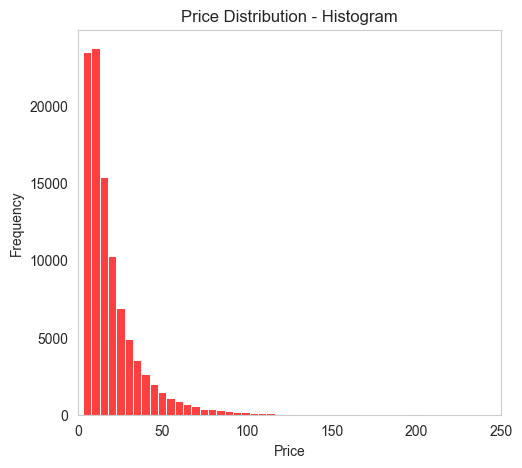

In [56]:
#              *** Plot the distribution of prices using histogram and box plot ***
import matplotlib.pyplot as plt
import seaborn as sns   
plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1) 
sns.histplot(df_ride['price'] , bins=40, color='red')
plt.title('Price Distribution - Histogram')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xlim(0, 250)  # Limit x-axis for better visibility
plt.grid()
plt.show()

In [57]:
#                 ***Calculate key statistics (mean, median, std, min, max)***

print(df_ride['price'].describe(), '\n') # this also gives the same statistics but I need individual values stored in variables to be used in further coding.

# Mean of price
price_mean = df_ride['price'].mean()
print("Mean of Price:", price_mean)

# Median of price
price_median = df_ride['price'].median()  
print("Median of Price:", price_median)  

# Min of price
price_min = df_ride['price'].min()
print("Min of Price:", price_min)

# Max of price
price_max = df_ride['price'].max()
print("Max of Price:", price_max)

# mode of price
price_mode = df_ride['price'].mode()[0]
print("Mode of Price:", price_mode)

# Std of price
price_std = df_ride['price'].std()  
print("Standard Deviation of Price:", price_std )

# we observe the min of price column is 3 as well the mode is also 3. So, there are many rides with minimum price of 3.
# Also checked the price data has only one mode value.


count    100000.000000
mean         19.585327
std          18.600097
min           3.000000
25%           8.190000
50%          13.600000
75%          24.000000
max         200.000000
Name: price, dtype: float64 

Mean of Price: 19.585327399999997
Median of Price: 13.6
Min of Price: 3.0
Max of Price: 200.0
Mode of Price: 3.0
Standard Deviation of Price: 18.60009697643764


In [58]:
df_ride['price'].value_counts().head(10)  # Display the top 10 most frequent prices

price
3.00    1088
6.73      80
7.19      77
7.16      75
8.13      74
9.03      72
8.44      72
6.29      72
6.82      71
7.03      71
Name: count, dtype: int64

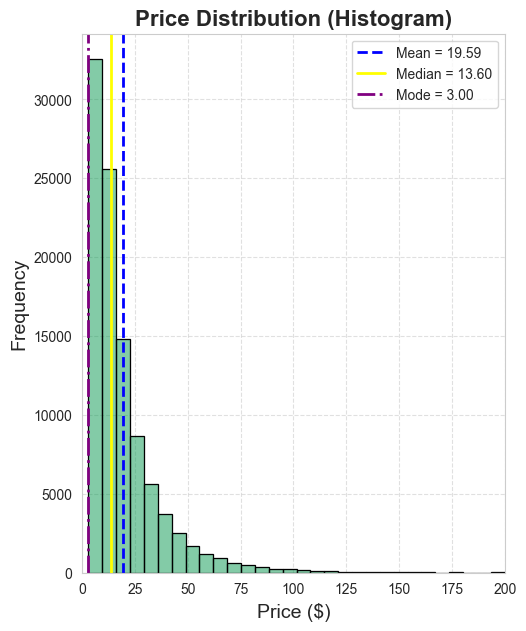

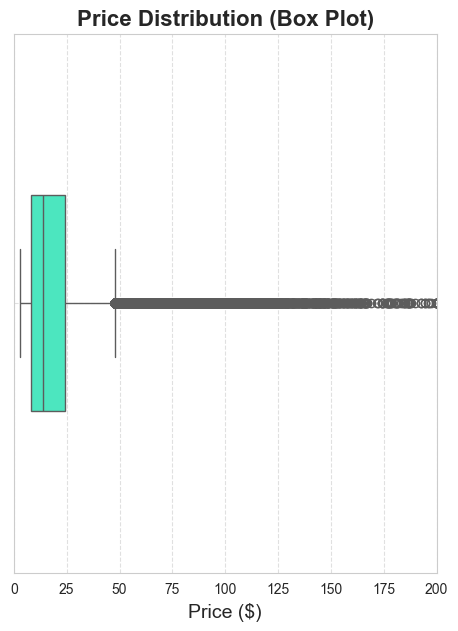

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns



plt.figure(figsize=(12, 7))

plt.subplot(1, 2, 1) 

sns.histplot(df_ride['price'], bins=30, color="#089950", edgecolor="#000000", alpha=0.5)

# Add vertical lines for mean & median

plt.axvline(price_mean, color='blue', linestyle='--', linewidth=2, label=f"Mean = {price_mean:.2f}")
plt.axvline(price_median, color='yellow', linestyle='-', linewidth=2, label=f"Median = {price_median:.2f}")
plt.axvline(price_mode, color='purple', linestyle='-.', linewidth=2, label=f"Mode = {price_mode:.2f}")


# Titles and labels
plt.title('Price Distribution (Histogram)', fontsize=16, weight='bold')
plt.xlabel('Price ($)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Limit x-axis for better visibility
plt.xlim(0, price_max)  # Focus on the entire min to max range

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# box plot
plt.figure(figsize=(12, 7))
plt.subplot(1, 2, 2)

sns.boxplot(x=df_ride['price'], color="#33FFCC", width=0.4)
plt.title('Price Distribution (Box Plot)', fontsize=16, weight='bold')
plt.xlabel('Price ($)', fontsize=14)        
plt.ylabel('')  # No y-axis label for box plot
plt.xlim(0, price_max)  # Focus on the entire min to max range
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()  


In [60]:
#             Histogram interpretation

# The price data is not normally distributed.
# The price distribution is right-skewed/positively skewed , with a long tail towards higher prices.
# The mean price ($ 19.6) is higher than the median ($ 13.6). mean > median > mode indicates right skewness.
# We have only 149 rides with price greater than 150 out of 1000000 rides. So, these are very few in number and can be considered as outliers.
# But these cannot be removed for model building because we have to predict the price for all ranges. So, we will keep them as it is.

#             Box plot interpretation

# The box plot confirms the right-skewed distribution of prices ( definitely not symmetrical )
# The median is closer to Q1 and the right whisker is longer. Indicates distribution is right-skewed (many small values, few large ones )
# The interquartile range (IQR) spans from approximately $10 to $24.This implies most of the prices (50% of the data) are within this range.
# There are a large number of points beyond 50, stretching all the way to near 200. 
# Only outliers beyond the right whiskers. As per boxplot these are potential outliers.
# These outliers show that while most prices are low, there are few very high ones.
# These outliers cannot be removed for model building because we have to predict the price for all ranges.


# Question 1.3: Feature Distribution Analysis (5 points)

In [61]:
# Plot distributions for all numerical features

# First I will sepertae numerical & categorical columns
numerical_cols = df_ride.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df_ride.select_dtypes(['object']).columns.tolist() 

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols) 




Numerical Columns: ['distance_miles', 'duration_minutes', 'hour', 'day_of_week', 'temperature', 'driver_rating', 'price']
Categorical Columns: ['weather', 'pickup_location', 'dropoff_location', 'vehicle_type']


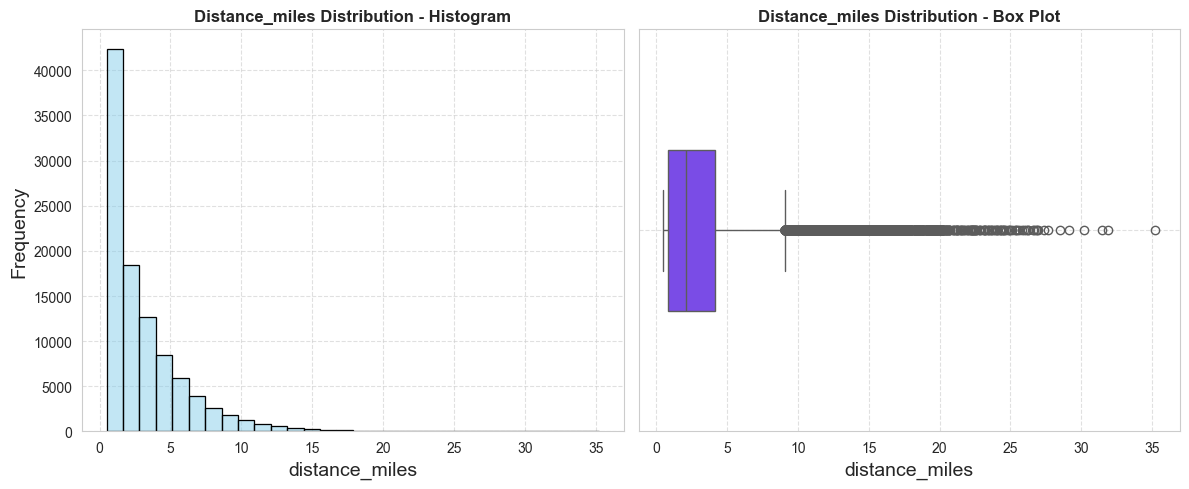

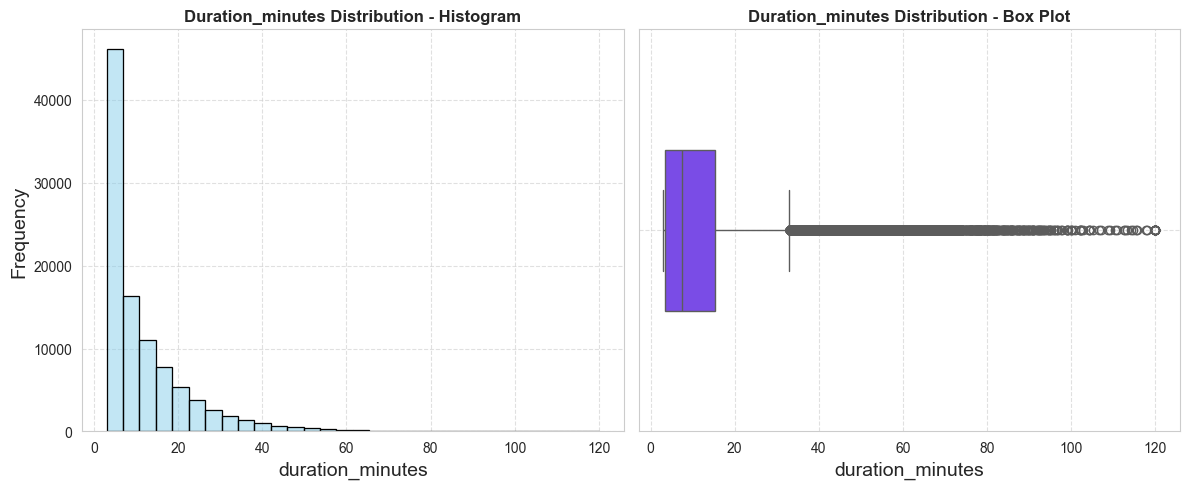

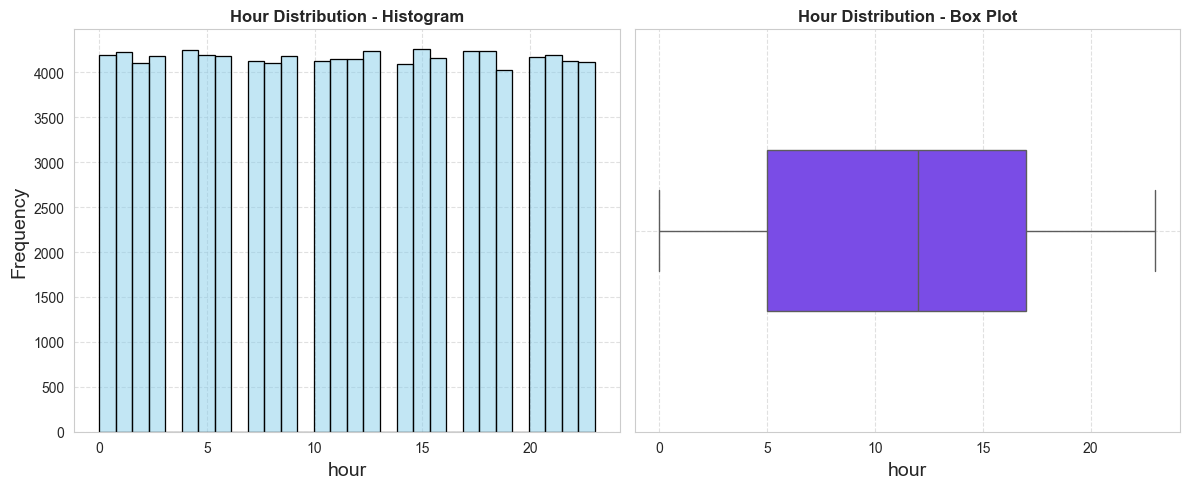

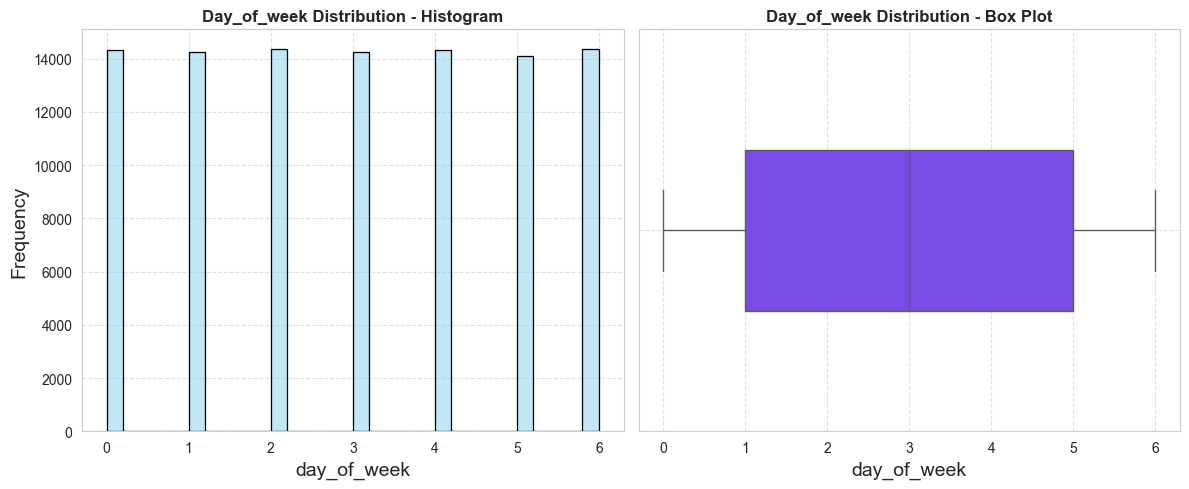

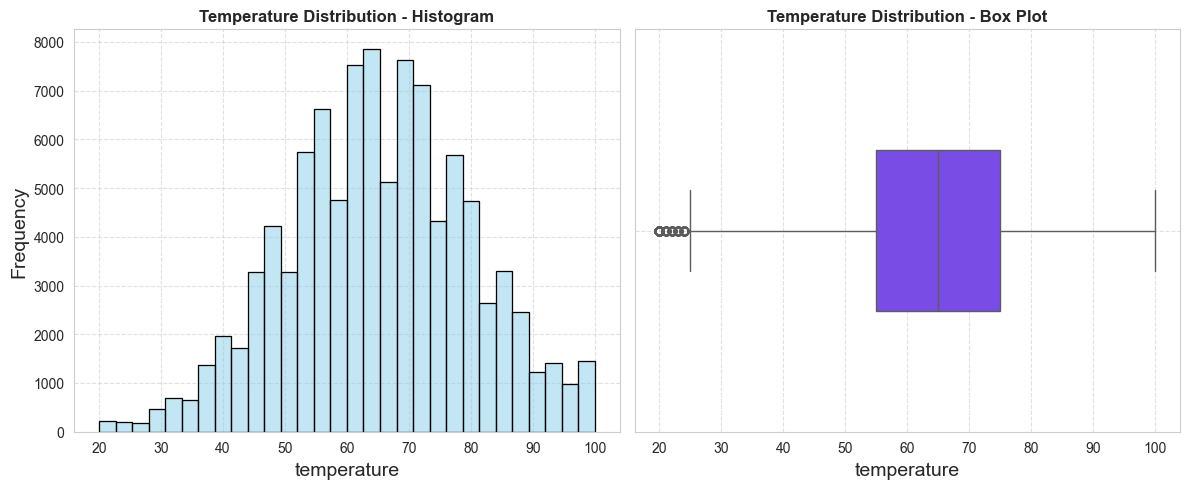

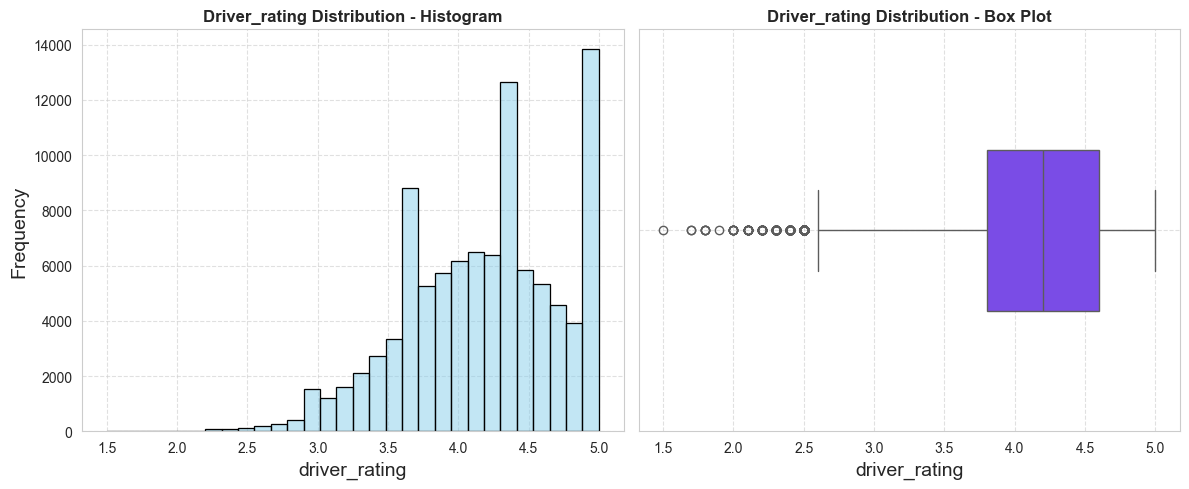

In [62]:
# Using a simple loop I will plot the distributions of all numerical features in the dataset using histograms and box plots.
# Capitalize column name in titles for better presentation.

for col in numerical_cols:
    if col == 'price':  # Skip price column as it's already plotted
        continue

    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)  # 1 → number of rows of subplots 2 → number of columns of subplots 1 → index of the current plot (first plot position)
    
    sns.histplot(df_ride[col], bins=30, color='skyblue', edgecolor="#000000", alpha=0.5)
    plt.title(f"{col.capitalize()} Distribution - Histogram", fontsize=12, weight='bold')  # col.capitalize() capitalizes the first letter of the column name
    plt.xlabel(col, fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)



    # Box plot
    plt.subplot(1, 2, 2) # 2 → index of the current plot (second plot position)
    sns.boxplot(x=df_ride[col], color="#7033FF", width=0.4)
    plt.title(f'{col.capitalize()} Distribution - Box Plot', fontsize=12, weight='bold')
    plt.xlabel(col, fontsize=14)
    plt.ylabel('')  # No y-axis label for box plot
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [63]:
                         # Interpretation of distributions:

# Same pattern of distribution is observed in distance, duration & price columns since they are inter- related. Longer distance , more time and high price.
#  All these three columns are right-skewed/positively skewed.

# The temperature column appears to be approximately normally distributed, with a slight left skew. Box plot shows few outliers exceeding left whisker.

# The hour and day_of_week columns are fairly uniformly and flat distributed.This shows that there is no particular peak hour or day for rides.

# Lastly , driver_rating column is left-skewed/negatively skewed. Most drivers have high ratings (4.5-5.0), with few lower ratings. Ratings below 2.5 are outliers as per box plot.


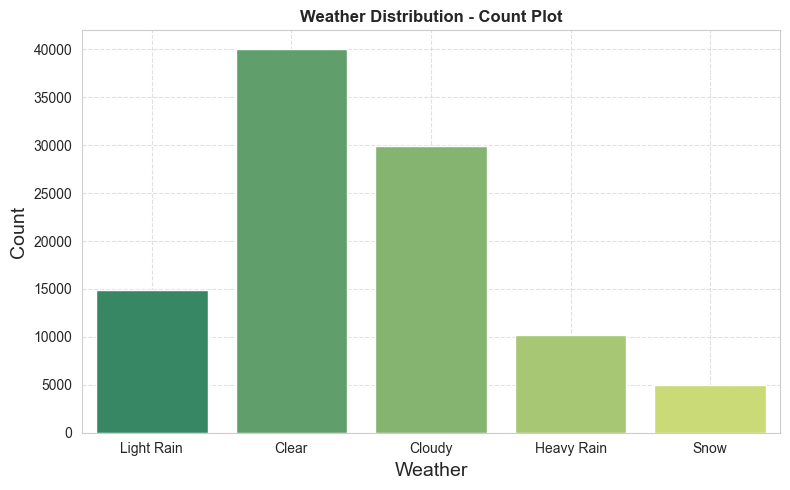

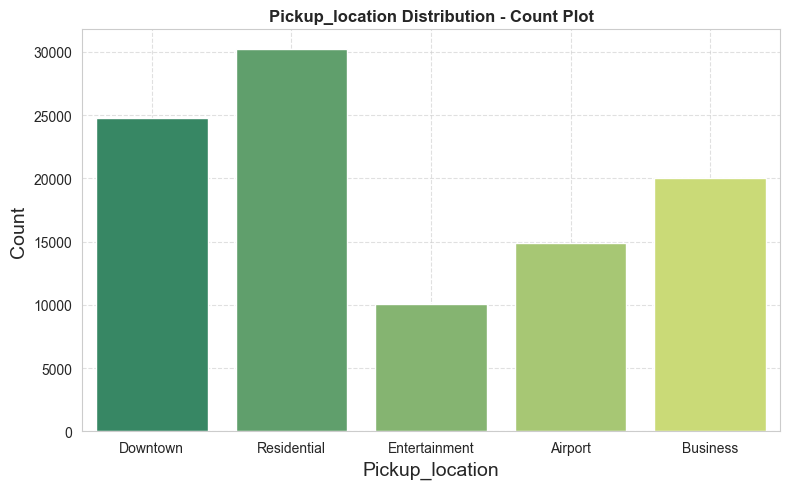

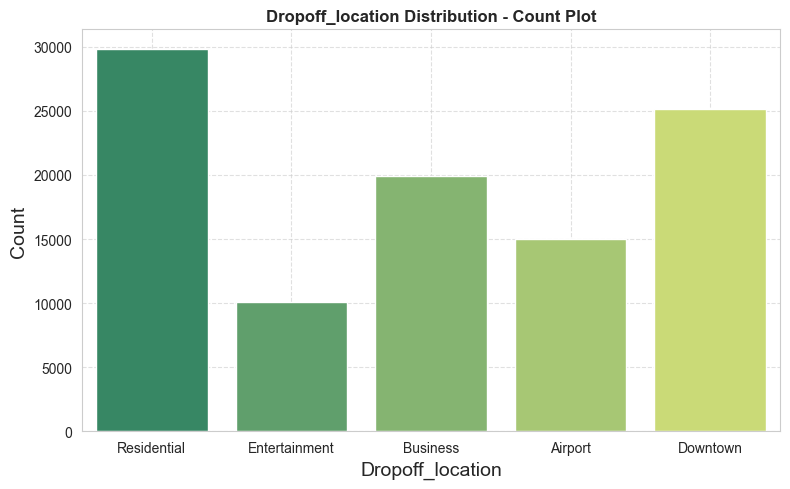

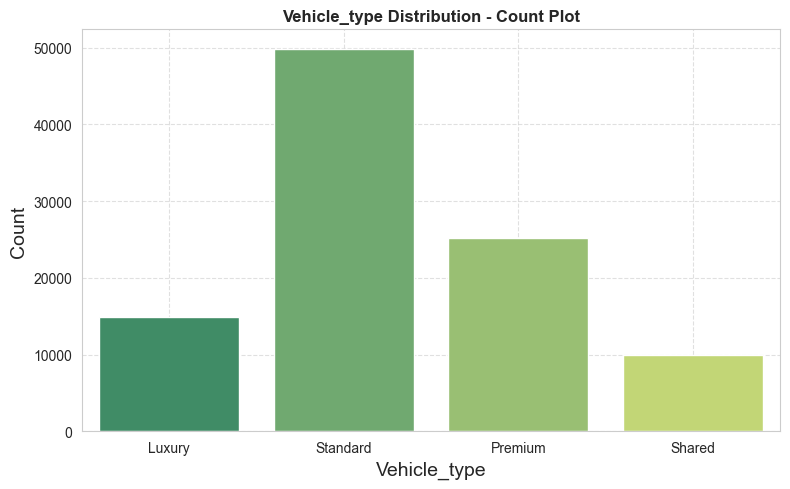

In [64]:
# Create count plots for categorical features

for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df_ride[col], hue=df_ride[col], palette="summer", legend=False)   #hue=df_ride[col] → tells Seaborn to color bars by the same variable as x.legend=False → avoids duplicate legends since x and hue are the same.
    plt.title(f'{col.capitalize()} Distribution - Count Plot', fontsize=12, weight='bold')
    plt.ylabel('Count', fontsize=14)
    plt.xlabel(col.capitalize(), fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [65]:
# Pickup_location == dropoff_location for many rides . I find this unusal. And highest number of rides are from/to location 'Residential'.

# Standard rides are mostly preferred compared to premium rides may be due to affordability.

# In case of weather column, most rides were taken in clear weather conditions. That is so obvious.


# Question 1.4: Correlation Analysis (5 points)

In [66]:
# Calculate correlation matrix for numerical features
# I am excludimg hour & day_of_week for correlation analysis , because instead of correlation, I will explore those with grouped averages.

# Dropping hour & day_of_week for correlation analysis

corr_df = df_ride.drop(columns=['hour','day_of_week'])
corr_matrix = corr_df.corr(numeric_only=True)
print(corr_matrix)  # Pearson correlation (default)
# Display the correlation matrix



                  distance_miles  duration_minutes  temperature  \
distance_miles          1.000000          0.927078    -0.005096   
duration_minutes        0.927078          1.000000    -0.005554   
temperature            -0.005096         -0.005554     1.000000   
driver_rating          -0.002399         -0.000868    -0.004265   
price                   0.764690          0.827543    -0.004131   

                  driver_rating     price  
distance_miles        -0.002399  0.764690  
duration_minutes      -0.000868  0.827543  
temperature           -0.004265 -0.004131  
driver_rating          1.000000 -0.003561  
price                 -0.003561  1.000000  


Text(0.5, 1.0, 'Correlation Matrix Heatmap')

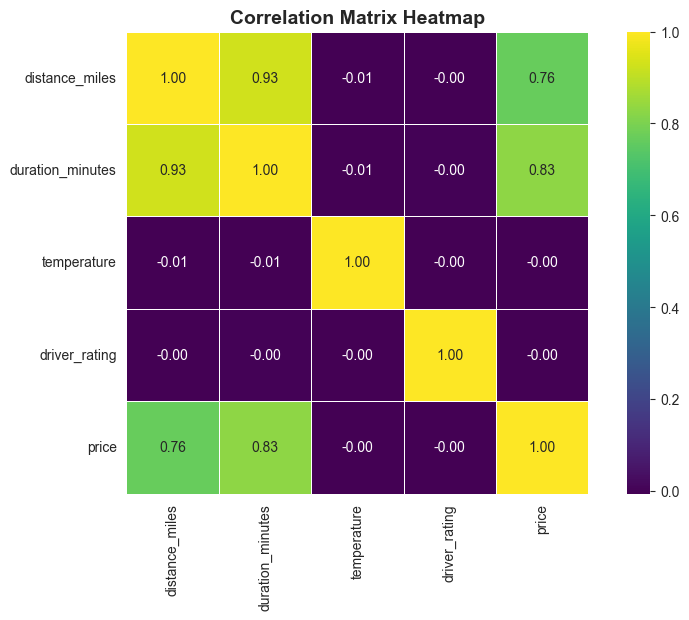

In [67]:
 # Heatmap of the correlation matrix for better visualization
plt.figure(figsize=(10, 6)) 
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="viridis", cbar=True, square=True, linewidths=0.5)
plt.title("Correlation Matrix Heatmap", fontsize=14, weight='bold')

# sns.heatmap(new_temp,annot=True,linewidth=0.5)

In [68]:
# The correlation matrix shows the following key relationships:
# The six square green box shows strong positive correlations exists in 3 pairs as follows :
    # Distance and Duration (0.93): Longer trips naturally take more time.  
    # Price with Distance (0.76) and Duration (0.78): Longer trips cost more.
    # Price with duration (0.83)


# Only 2 features correlated with price : distance_miles , duration_minutes

# High correlation between distance_miles and duration_minutes (0.93) 
# Multicollinearity problem may arise in machine learning models (like regression), keeping both in model training.


# Part 2: Exploratory Data Analysis (25 points)

## Question 2.1: Price vs Distance Analysis (5 points)

In [69]:
df_ride.columns

Index(['distance_miles', 'duration_minutes', 'hour', 'day_of_week', 'weather',
       'temperature', 'pickup_location', 'dropoff_location', 'vehicle_type',
       'driver_rating', 'price'],
      dtype='object')

<Axes: xlabel='distance_miles', ylabel='price'>

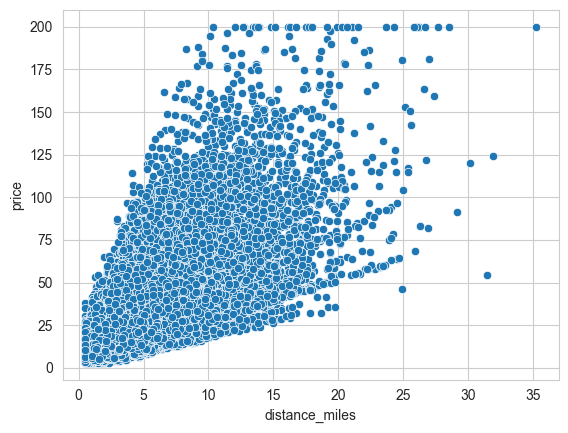

In [70]:
sns.scatterplot(df_ride, x='distance_miles', y='price')

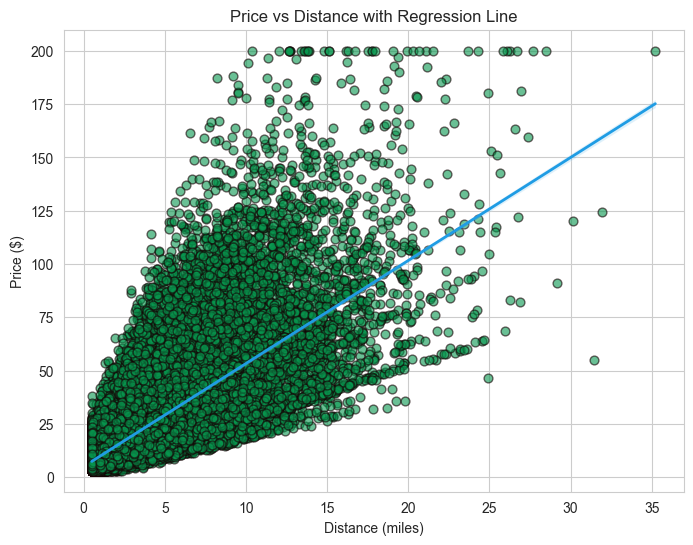

In [71]:
plt.figure(figsize=(8, 6))
sns.regplot(
    data=df_ride,
    x="distance_miles",
    y="price",
    scatter_kws={"alpha": 0.6,    # transparency
                     "s": 40,         # marker size
                     "color": "#07964E", # marker color
                     "edgecolor": "#140304", # outline
                     },    # transparency of points
    line_kws={"color": "#1F9CE4", "lw": 2}  # regression line style
)

plt.title("Price vs Distance with Regression Line")
plt.xlabel("Distance (miles)")
plt.ylabel("Price ($)")
plt.show()




In [72]:

# I can take this coefficent value from corr_matrix but I am calculating here individually

dist_price_corr = df_ride["distance_miles"].corr(df_ride["price"])
print(f"Correlation coefficient Price and distance: {dist_price_corr:.2f}")  # using f string function

# print("Correlation coefficient Price and distance :", round(dist_price_corr,2)) # using round command


Correlation coefficient Price and distance: 0.76


In [73]:
# The value 0.76 of the correlation coefficient suggest strong positive correlation between Price and distance.
# This implies price becomes higher for longer distance and vice versa.

# Question 2.2: Temporal Patterns Analysis (10 points)

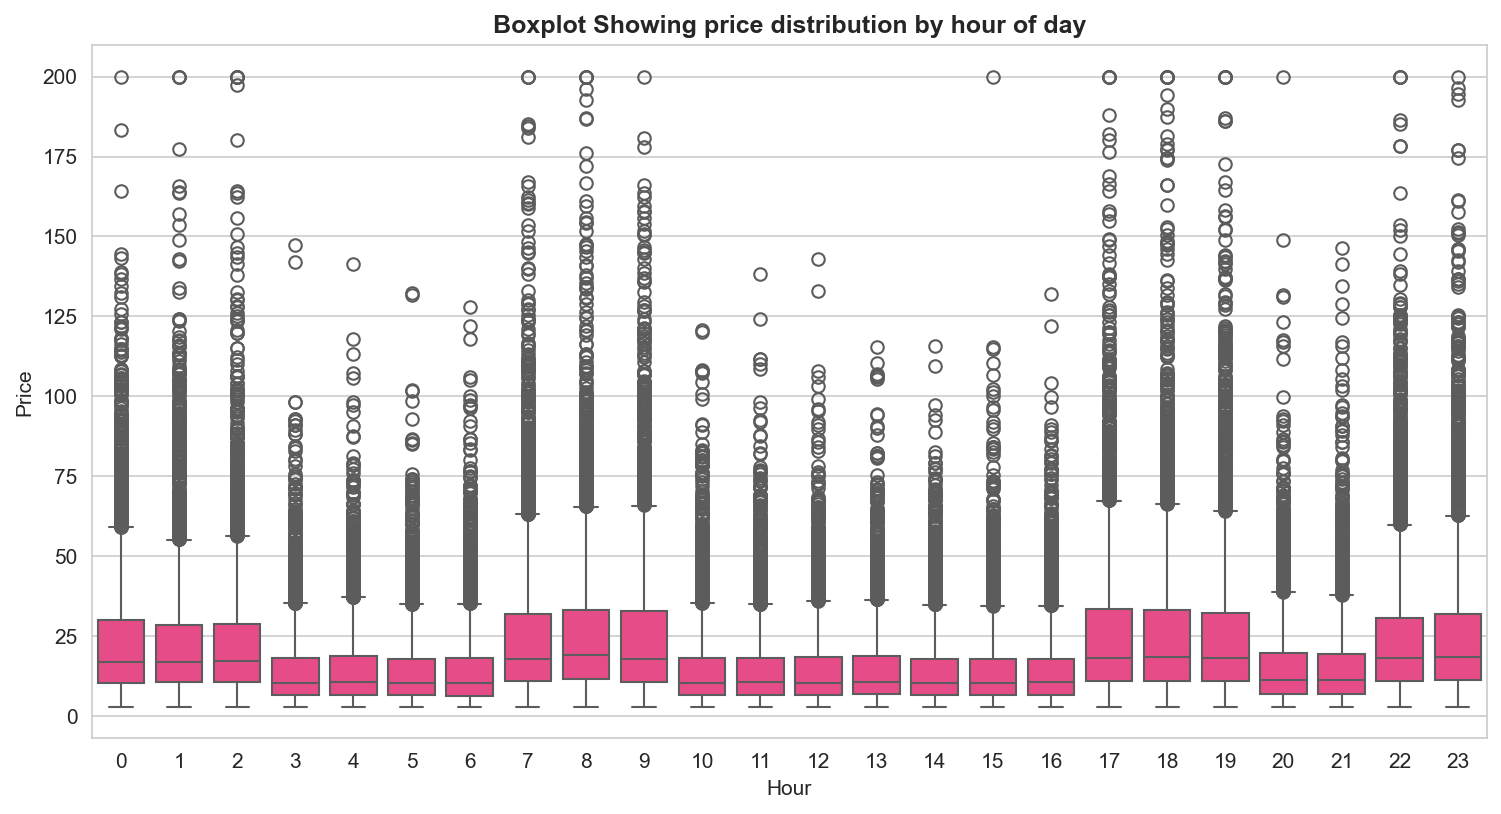

In [74]:
#            Analyze temporal patterns in pricing:

# Create box plots showing price distribution by hour of day

plt.figure(figsize=(12,6), dpi = 150)
sns.set_style("whitegrid")

sns.boxplot(data = df_ride, x='hour', y = 'price',color="#FF3381")

plt.title("Boxplot Showing price distribution by hour of day",weight='bold')
plt.xlabel("Hour")
plt.ylabel("Price")

plt.show()


In [75]:
                # Interpretaion Boxplot Showing price distribution by hour of day

# Hour of the day (0-23)
# Rush hours morning 7 am - 9 pm , at evening 5 pm - 7 pm since high avg prices during these hours.
# High prices during ( 10 pm - 3 am) can be reasoned late night 

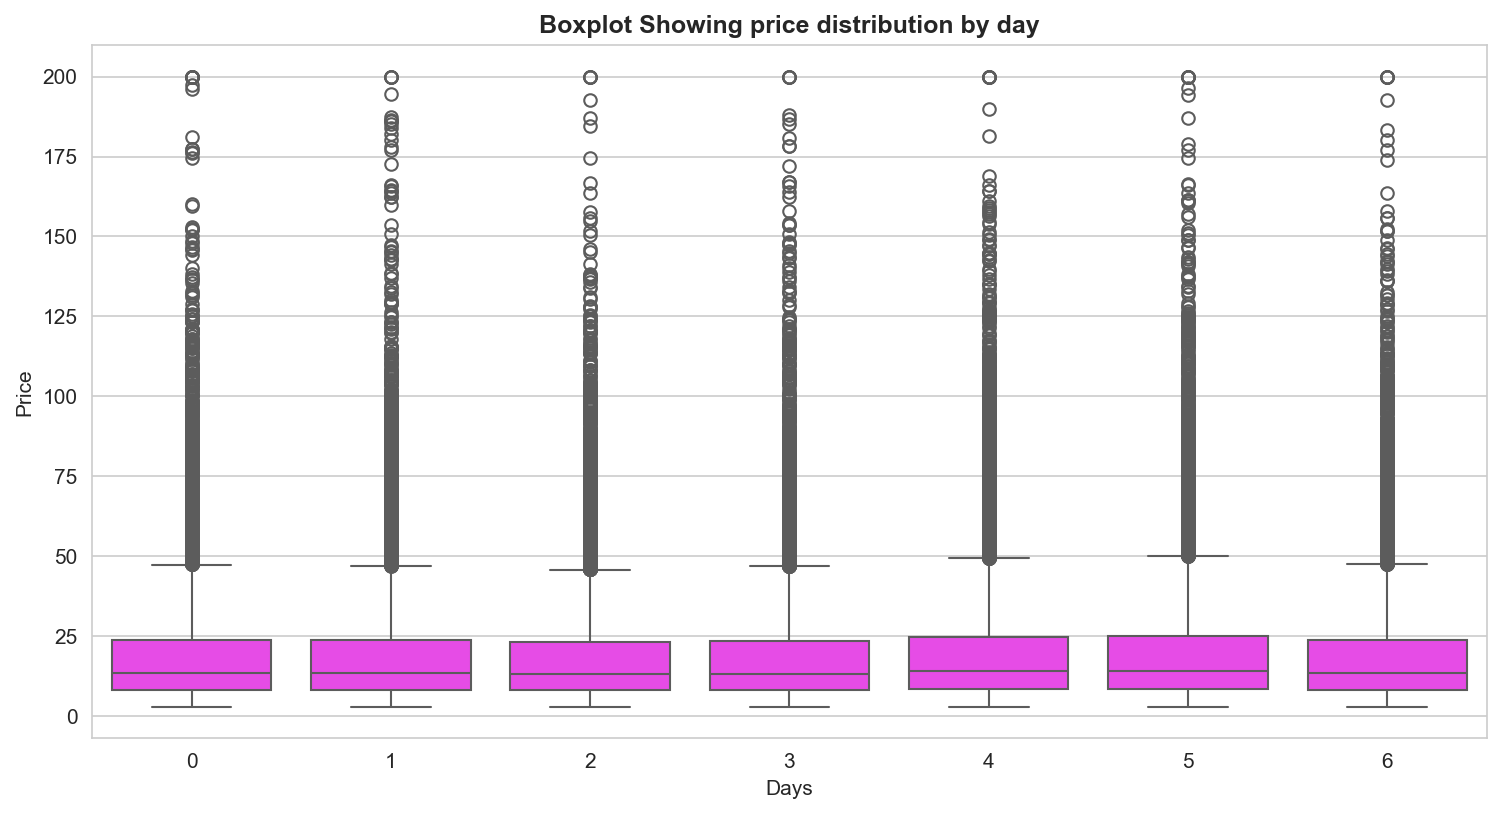

In [76]:
# Create box plots showing price distribution by day of week

plt.figure(figsize=(12,6), dpi = 150)
sns.set_style("whitegrid")

sns.boxplot(data = df_ride, x='day_of_week', y = 'price',color="#FF33FFCC")

plt.title("Boxplot Showing price distribution by day",weight='bold')
plt.xlabel("Days")
plt.ylabel("Price")

plt.show()

In [77]:

#                 * Interpretation *

# Day of week (0=Monday, 6=Sunday)
# The average on Day 4 and Day 5 (Friday and Saturday) is slightly higher, around 20, possibly due to the days preceding the weekend.
# Other than this no such varieties in days avg prices . All days are similarly happy days !!!


In [78]:
# Calculate average price by time periods

# Avg price by hour of day


print(df_ride.groupby('hour')['price'].mean())


#                * Interpretation *

# Hour of the day (0-23)
# Rush hours morning 7 am - 9 am , at evening 5 pm - 7 pm (17,18,19) since high avg prices during these hours.
# High prices during ( 10 pm - 3 am) can be reasoned late night.

hour
0     23.725580
1     23.260403
2     23.579654
3     14.482690
4     14.860684
5     14.376365
6     14.533903
7     25.534571
8     26.333935
9     25.713350
10    14.799714
11    14.626037
12    14.690550
13    14.861587
14    14.419084
15    14.518565
16    14.542617
17    26.052074
18    26.601324
19    26.114330
20    15.969010
21    15.877255
22    25.134369
23    25.879020
Name: price, dtype: float64


In [79]:
print(df_ride.groupby('day_of_week')['price'].mean())

#                * Interpretation *

# Day of week (0=Monday, 6=Sunday)
# The average on Day 4 and Day 5 (Friday and Saturday) is slightly higher, around 20, possibly due to the days preceding the weekend.
# Other than this no such varieties in days avg prices . All days are similarly happy days !!!

day_of_week
0    19.471876
1    19.517483
2    18.929464
3    19.246275
4    20.199138
5    20.417189
6    19.329638
Name: price, dtype: float64


# Question 2.3: Categorical Features Impact (10 points)

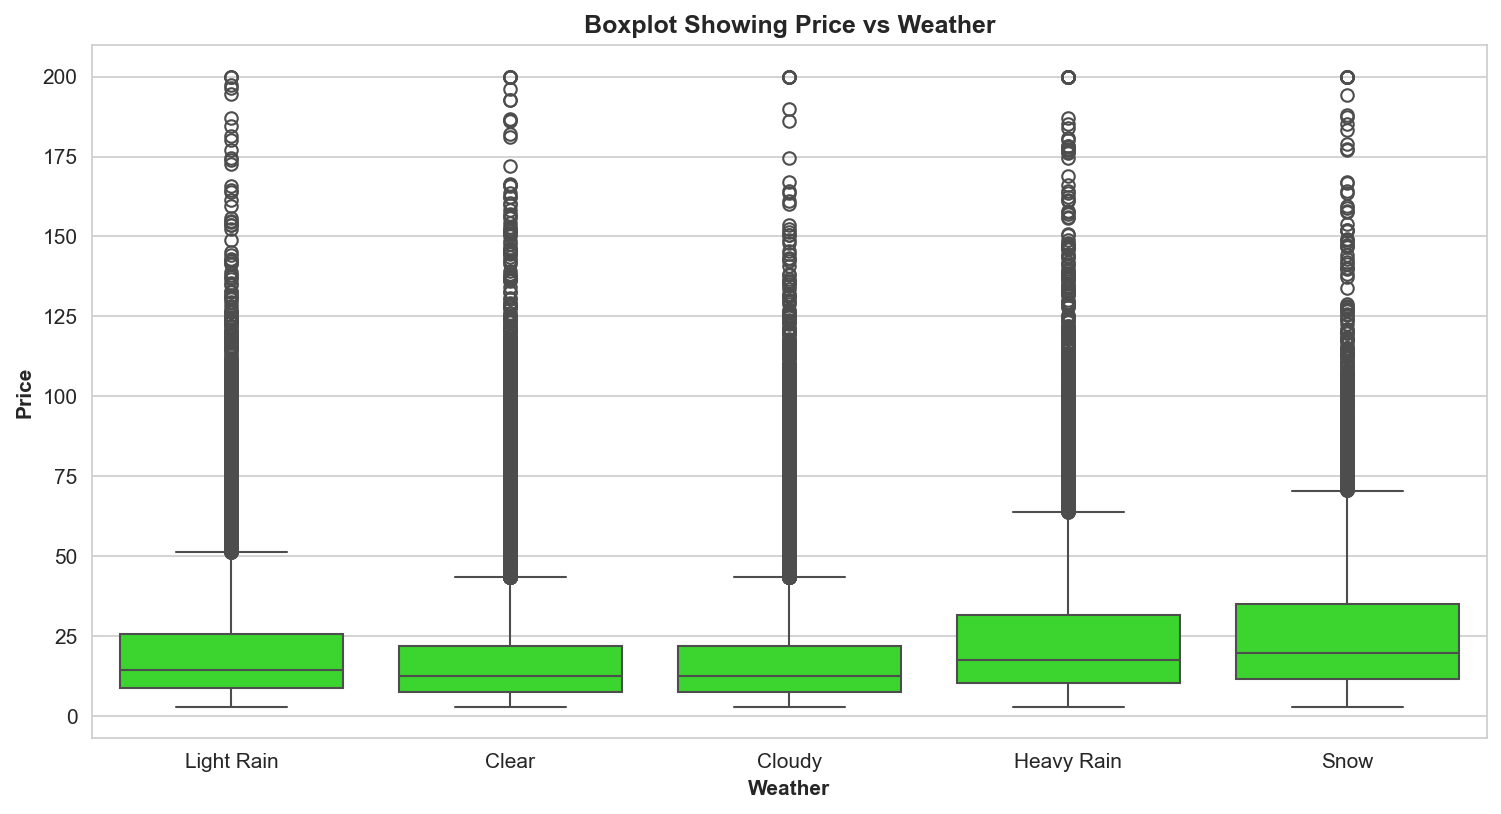

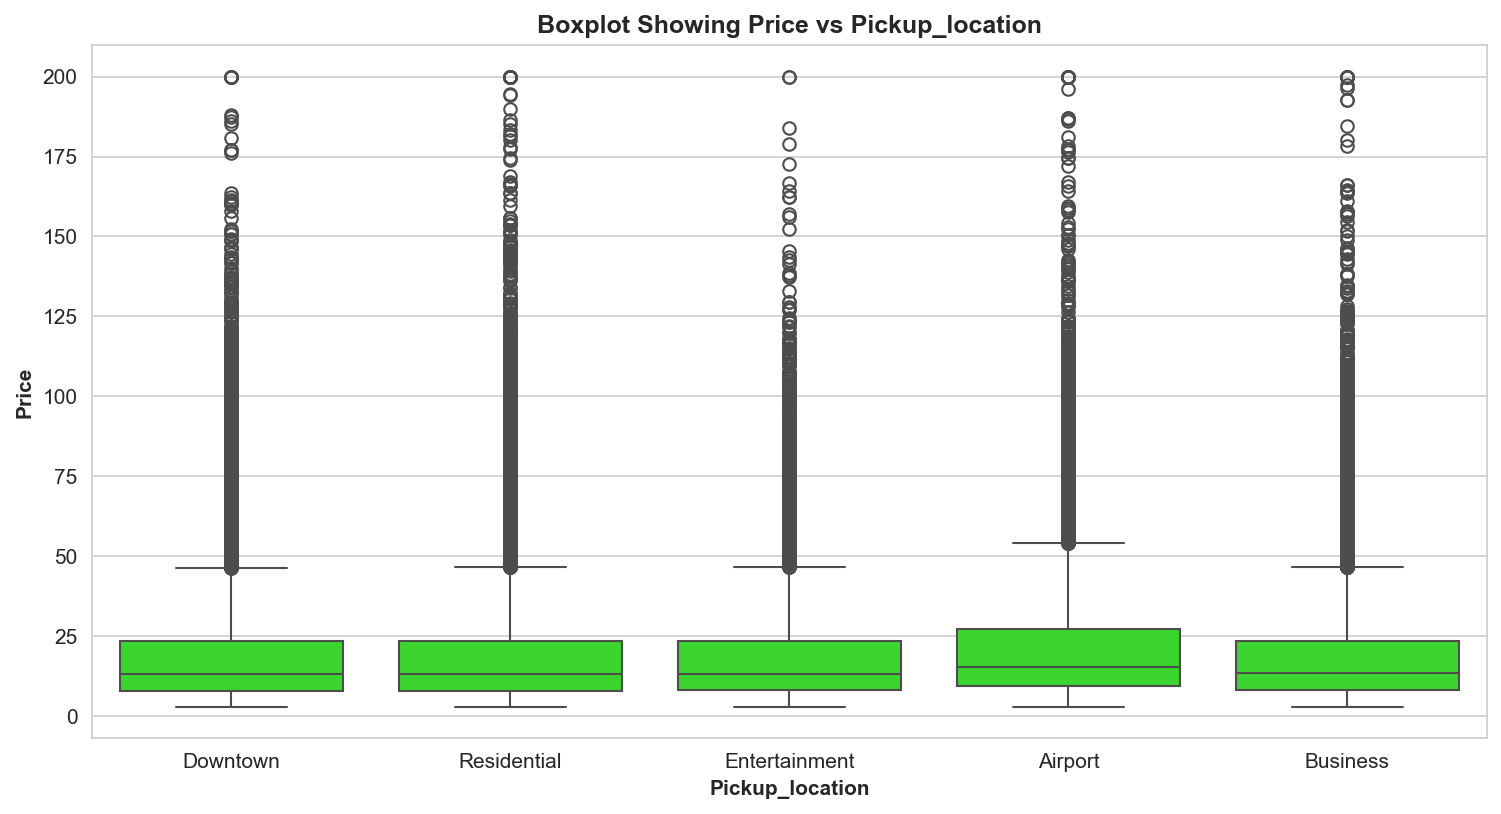

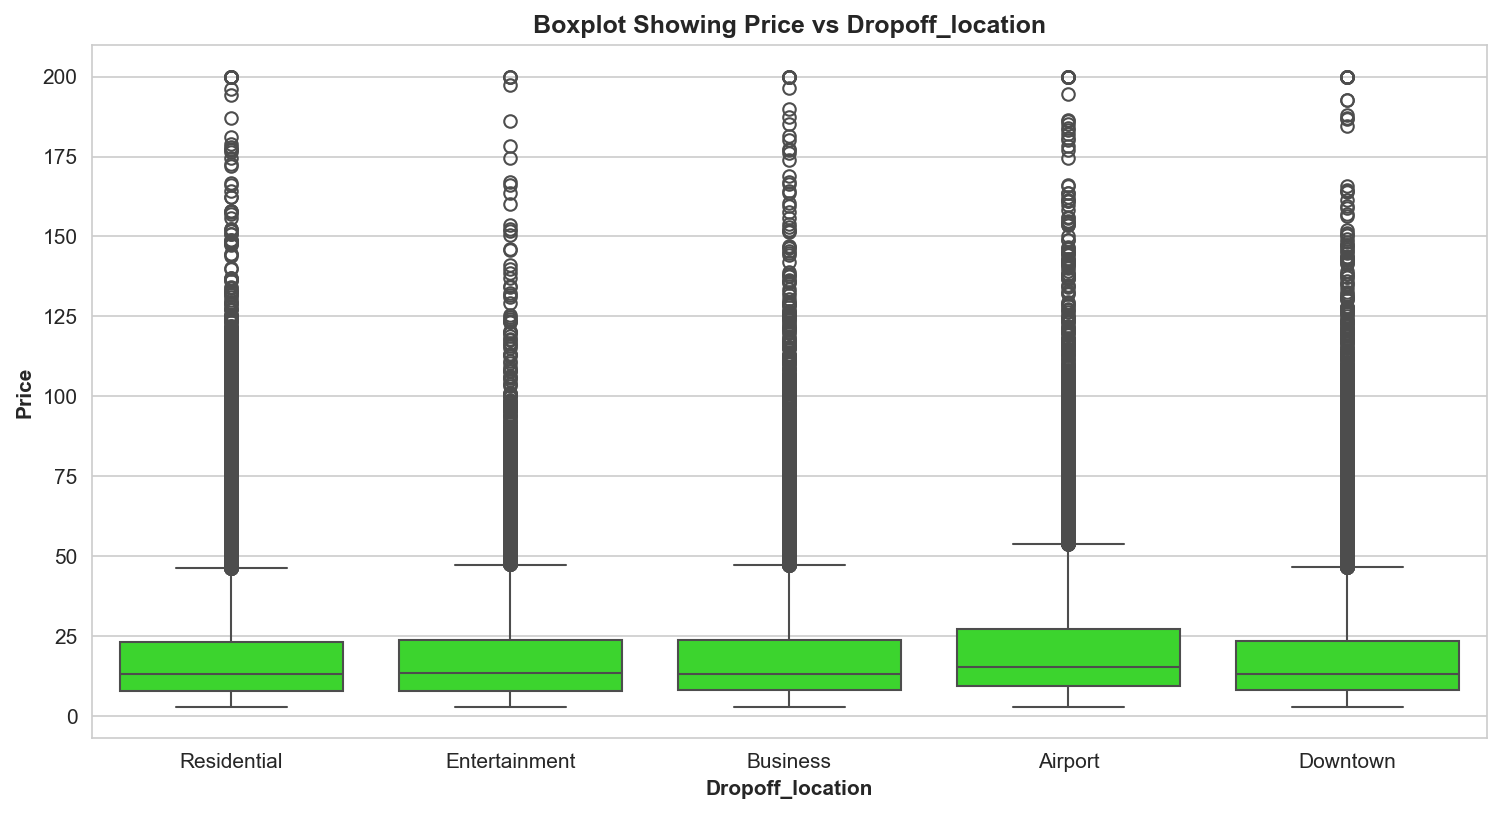

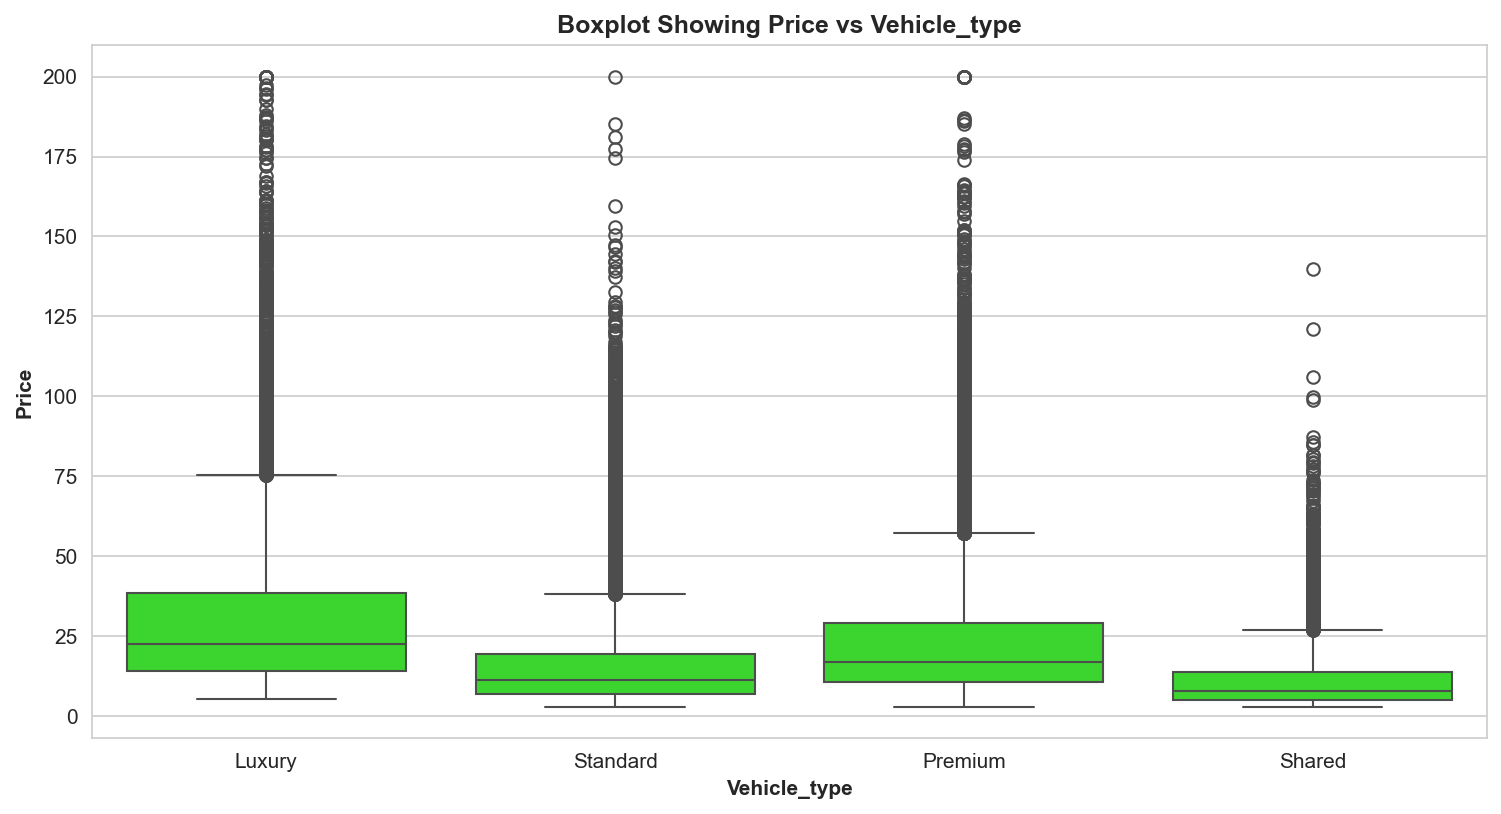

In [80]:
# Create box plots for price vs weather conditions
# Create box plots for price vs vehicle type
# Create box plots for price vs pickup/dropoff locations


columns_boxplot = ["weather","pickup_location", "dropoff_location", "vehicle_type"] # Creating list of all categorical columns for boxplot

for column in columns_boxplot :
    plt.figure(figsize=(12,6), dpi = 150)
    sns.set_style("whitegrid")

    sns.boxplot(data = df_ride, x=df_ride[column],y = 'price',color="#25F012")

    plt.title((f"Boxplot Showing Price vs {column.capitalize()}"),weight='bold')
    plt.xlabel(column.capitalize(),weight='bold')
    plt.ylabel("Price",weight='bold')
    plt.show()

In [81]:
# Calculate average price for each category
# Identify which categories command premium pricing

for column in columns_boxplot :
    avg_price_category = df_ride.groupby(column)['price'].mean().sort_values(ascending= False)
    print(f"Averge price by {column} \n  {avg_price_category} \n")

Averge price by weather 
  weather
Snow          28.097480
Heavy Rain    25.476359
Light Rain    20.817172
Clear         17.880555
Cloudy        17.823261
Name: price, dtype: float64 

Averge price by pickup_location 
  pickup_location
Airport          22.175483
Entertainment    19.238614
Business         19.150992
Residential      19.128249
Downtown         19.076829
Name: price, dtype: float64 

Averge price by dropoff_location 
  dropoff_location
Airport          22.129775
Entertainment    19.237409
Business         19.223147
Downtown         19.145825
Residential      19.035538
Name: price, dtype: float64 

Averge price by vehicle_type 
  vehicle_type
Luxury      31.303847
Premium     23.610292
Standard    15.730984
Shared      11.211223
Name: price, dtype: float64 



In [82]:
#              * Interpretation *

# Weather: Prices spike in bad weather conditions (esp. Snow & heavy rain )

# Airport trips demands high fares than other locations.

# Luxury and premium vehical_type charge significantly more .

# Part 3: Data Preprocessing and Feature Engineering (20 points)

In [83]:
                  # Question 3.1: Handle Missing Values (5 points)

# Total missing values in temperature column is  1228 .
# Total missing values in driver_rating column is  1272

temperature_mean = df_ride['temperature'].mean()
print("Tempearture mean = ", temperature_mean) # The temperature column appears to be approximately normally distributed. So i will use mean to fill na.


df_ride['temperature'] = df_ride['temperature'].fillna(temperature_mean)

df_ride['temperature'].isna().sum()  # checking if imputation correctly done


Tempearture mean =  64.94728263070506


np.int64(0)

In [84]:


driver_rating_mean = df_ride['driver_rating'].mean()
print("Driver_rating mean = ", driver_rating_mean)

driver_rating_mode = df_ride['driver_rating'].mode()
print("Driver_rating mode = ", driver_rating_mode[0])

df_ride['driver_rating'].value_counts().head(10)

# Since driver_rating colimn is left skewed and a type of categorical feature as well 
# so I am considering mode as fillna option.


Driver_rating mean =  4.174448991167653
Driver_rating mode =  5.0


driver_rating
5.0    10511
4.1     6498
4.3     6469
4.2     6394
4.4     6176
4.0     6171
4.5     5827
3.9     5723
4.6     5331
3.8     5257
Name: count, dtype: int64

In [85]:
df_ride['driver_rating'] = df_ride['driver_rating'].fillna(driver_rating_mode[0])


In [86]:
df_ride['driver_rating'].isna().sum() 

df_ride.isna().sum()           #  Finally Clean data with no missing values

distance_miles      0
duration_minutes    0
hour                0
day_of_week         0
weather             0
temperature         0
pickup_location     0
dropoff_location    0
vehicle_type        0
driver_rating       0
price               0
dtype: int64

# Question 3.4: Feature Engineering (5 points)

### This part needs to be done before applying Scaling an Encoding methods. 

In [87]:

# Create new features to improve model performance:                                           
# Create at least 2 new features from existing ones (e.g., is_weekend, is_rush_hour)
# Create interaction features if meaningful
# Explain the business logic behind each new feature

new_df = df_ride.copy()
new_df['is_weekend'] = new_df['day_of_week'].isin([5,6]).astype(int)   # .astype(int) -> Converts the boolean values (True/False) into integer

# Rush hours morning 7 am - 9 am , at evening 5 pm - 7 pm  (17,18,19) since high avg prices during these hours.

new_df['is_rush_hour'] = new_df['hour'].isin([7,8,9,17,18,19]).astype(int)

new_df['trip_speed_mph'] = new_df['distance_miles'] / (new_df['duration_minutes'] / 60)

print(new_df)


#         * The new features created are:
# 1. is_weekend: A binary feature indicating if the ride occurred on a weekend (1) or a weekday (0). Weekend rides may have different pricing dynamics due to leisure travel.
# 2. is_rush_hour: A binary feature indicating if the ride occurred during typical rush hours (1) or not (0). Rush hour rides may command higher prices due to increased demand and traffic congestion.
# 3. trip_speed_mph: A continuous feature representing the average speed of the trip in miles per hour. This feature can help identify unusually slow trips that may be affected by traffic or route inefficiencies, potentially impacting pricing.

       distance_miles  duration_minutes  hour  day_of_week     weather  \
0                1.41               6.3     1            1  Light Rain   
1                9.03              40.8     7            6       Clear   
2                3.95              13.8    14            6       Clear   
3                2.74               8.2    16            6  Light Rain   
4                0.51               3.0     5            5  Light Rain   
...               ...               ...   ...          ...         ...   
99995            4.72              13.3    23            2       Clear   
99996            4.53              21.5    17            2       Clear   
99997            3.37              15.4    17            6       Clear   
99998            2.08               7.9     7            4      Cloudy   
99999            1.48               4.1    22            4  Light Rain   

       temperature pickup_location dropoff_location vehicle_type  \
0             78.0        Downtown      Res

# Question 3.2: Encode Categorical Variables (5 points)


In [88]:
# Identify categorical columns that need encoding
# Choose appropriate encoding method (Label Encoding vs One-Hot Encoding)
# Implement the encoding
# Show before and after comparison

In [89]:
#   One hot coding for categorical features :

   #   weather
   #   vehicle_type
   #   dropoff_location
   #   pickup_location

# Cyclical Encoding 
   # hour
   # day_of_week

# Here *Label Encoding* not needed since neither of the categorical columns in this dataset involves ordinal feature.

In [90]:
 
df_ride_encoded = new_df.copy()
df_ride_encoded = pd.get_dummies(df_ride_encoded, columns=['weather', 'vehicle_type', 'dropoff_location', 'pickup_location'], drop_first=True, dtype=int)
print(df_ride_encoded.sample(5))
 
 # This code snippet loads the dataset, creates dummy variables for each categorical columns, and drops the first dummy variable to avoid multicollinearity.

       distance_miles  duration_minutes  hour  day_of_week  temperature  \
20459            1.75               9.0     8            0         65.0   
12277            2.76               9.3    14            1         69.0   
87812            3.47              10.3     3            3         48.0   
24578            0.50               3.0    13            1         65.0   
62088            1.09               3.3    11            2         53.0   

       driver_rating  price  is_weekend  is_rush_hour  trip_speed_mph  ...  \
20459            4.0  17.06           0             1       11.666667  ...   
12277            4.4  12.01           0             0       17.806452  ...   
87812            4.5  11.98           0             0       20.213592  ...   
24578            4.1   5.08           0             0       10.000000  ...   
62088            4.5   7.28           0             0       19.818182  ...   

       vehicle_type_Shared  vehicle_type_Standard  dropoff_location_Business  \


In [91]:
print(f"Before -> {new_df.shape}")
print("After encoding ->" , df_ride_encoded.shape)

Before -> (100000, 14)
After encoding -> (100000, 25)


In [92]:
         #   CYCLIC ENCODING 'hour'
# With cyclic encodning the adjucency problem is resolved and correlation values will be meaningful , so for hour and day_of_week choose this method.
df_ride_encoded['hour_sin'] = np.sin(2 * np.pi * df_ride_encoded['hour'] / 24)
df_ride_encoded['hour_cos'] = np.cos(2 * np.pi * df_ride_encoded['hour'] / 24)

df_ride_encoded.head(10)


,distance_miles,duration_minutes,hour,day_of_week,temperature,driver_rating,price,is_weekend,is_rush_hour,trip_speed_mph,...,dropoff_location_Business,dropoff_location_Downtown,dropoff_location_Entertainment,dropoff_location_Residential,pickup_location_Business,pickup_location_Downtown,pickup_location_Entertainment,pickup_location_Residential,hour_sin,hour_cos
0,1.41,6.3,1,1,78.0,4.4,20.62,0,0,13.428571,...,0,0,0,1,0,1,0,0,0.258819,0.965926
1,9.03,40.8,7,6,93.0,4.7,48.30,1,1,13.279412,...,0,0,1,0,0,1,0,0,0.965926,-0.258819
2,3.95,13.8,14,6,49.0,4.6,12.71,1,0,17.173913,...,1,0,0,0,0,0,0,1,-0.500000,-0.866025
3,2.74,8.2,16,6,59.0,3.8,14.38,1,0,20.048780,...,1,0,0,0,0,0,1,0,-0.866025,-0.500000
4,0.51,3.0,5,5,31.0,4.5,6.47,1,0,10.200000,...,0,0,1,0,0,0,0,0,0.965926,0.258819
5,0.51,3.2,21,1,74.0,3.4,5.04,0,0,9.562500,...,1,0,0,0,1,0,0,0,-0.707107,0.707107
6,0.50,3.0,22,5,71.0,5.0,22.32,1,0,10.000000,...,0,0,0,0,0,0,0,1,-0.500000,0.866025
7,6.03,20.0,5,3,56.0,3.3,19.10,0,0,18.090000,...,0,1,0,0,1,0,0,0,0.965926,0.258819
8,2.76,7.9,13,0,89.0,3.6,10.28,0,0,20.962025,...,0,1,0,0,1,0,0,0,-0.258819,-0.965926
9,3.69,14.4,16,5,93.0,3.3,12.80,1,0,15.375000,...,1,0,0,0,1,0,0,0,-0.866025,-0.500000


In [93]:
#              CYCLIC ENCODING 'day_of_week'

df_ride_encoded['dow_sin'] = np.sin(2 * np.pi * df_ride_encoded['day_of_week'] / 7)
df_ride_encoded['dow_cos'] = np.cos(2 * np.pi * df_ride_encoded['day_of_week'] / 7)

df_ride_encoded.head(10)


,distance_miles,duration_minutes,hour,day_of_week,temperature,driver_rating,price,is_weekend,is_rush_hour,trip_speed_mph,...,dropoff_location_Entertainment,dropoff_location_Residential,pickup_location_Business,pickup_location_Downtown,pickup_location_Entertainment,pickup_location_Residential,hour_sin,hour_cos,dow_sin,dow_cos
0,1.41,6.3,1,1,78.0,4.4,20.62,0,0,13.428571,...,0,1,0,1,0,0,0.258819,0.965926,0.781831,0.623490
1,9.03,40.8,7,6,93.0,4.7,48.30,1,1,13.279412,...,1,0,0,1,0,0,0.965926,-0.258819,-0.781831,0.623490
2,3.95,13.8,14,6,49.0,4.6,12.71,1,0,17.173913,...,0,0,0,0,0,1,-0.500000,-0.866025,-0.781831,0.623490
3,2.74,8.2,16,6,59.0,3.8,14.38,1,0,20.048780,...,0,0,0,0,1,0,-0.866025,-0.500000,-0.781831,0.623490
4,0.51,3.0,5,5,31.0,4.5,6.47,1,0,10.200000,...,1,0,0,0,0,0,0.965926,0.258819,-0.974928,-0.222521
5,0.51,3.2,21,1,74.0,3.4,5.04,0,0,9.562500,...,0,0,1,0,0,0,-0.707107,0.707107,0.781831,0.623490
6,0.50,3.0,22,5,71.0,5.0,22.32,1,0,10.000000,...,0,0,0,0,0,1,-0.500000,0.866025,-0.974928,-0.222521
7,6.03,20.0,5,3,56.0,3.3,19.10,0,0,18.090000,...,0,0,1,0,0,0,0.965926,0.258819,0.433884,-0.900969
8,2.76,7.9,13,0,89.0,3.6,10.28,0,0,20.962025,...,0,0,1,0,0,0,-0.258819,-0.965926,0.000000,1.000000
9,3.69,14.4,16,5,93.0,3.3,12.80,1,0,15.375000,...,0,0,1,0,0,0,-0.866025,-0.500000,-0.974928,-0.222521


In [94]:
# Now I will drop original hour & day_of_week columns .

df_ride_encoded = df_ride_encoded.drop(columns=['hour','day_of_week'],axis=1)


# Question 3.3: Feature Scaling (5 points)


In [95]:
# Apply feature scaling:

# Determine which features need scaling
# Choose appropriate scaling method (StandardScaler vs MinMaxScaler)
# Apply scaling only to training data
# Explain why scaling is important for ML models

In [96]:
df_ride_encoded.head()

,distance_miles,duration_minutes,temperature,driver_rating,price,is_weekend,is_rush_hour,trip_speed_mph,weather_Cloudy,weather_Heavy Rain,...,dropoff_location_Entertainment,dropoff_location_Residential,pickup_location_Business,pickup_location_Downtown,pickup_location_Entertainment,pickup_location_Residential,hour_sin,hour_cos,dow_sin,dow_cos
0,1.41,6.3,78.0,4.4,20.62,0,0,13.428571,0,0,...,0,1,0,1,0,0,0.258819,0.965926,0.781831,0.623490
1,9.03,40.8,93.0,4.7,48.30,1,1,13.279412,0,0,...,1,0,0,1,0,0,0.965926,-0.258819,-0.781831,0.623490
2,3.95,13.8,49.0,4.6,12.71,1,0,17.173913,0,0,...,0,0,0,0,0,1,-0.500000,-0.866025,-0.781831,0.623490
3,2.74,8.2,59.0,3.8,14.38,1,0,20.048780,0,0,...,0,0,0,0,1,0,-0.866025,-0.500000,-0.781831,0.623490
4,0.51,3.0,31.0,4.5,6.47,1,0,10.200000,0,0,...,1,0,0,0,0,0,0.965926,0.258819,-0.974928,-0.222521


In [97]:
df_ride_encoded.columns

Index(['distance_miles', 'duration_minutes', 'temperature', 'driver_rating',
       'price', 'is_weekend', 'is_rush_hour', 'trip_speed_mph',
       'weather_Cloudy', 'weather_Heavy Rain', 'weather_Light Rain',
       'weather_Snow', 'vehicle_type_Premium', 'vehicle_type_Shared',
       'vehicle_type_Standard', 'dropoff_location_Business',
       'dropoff_location_Downtown', 'dropoff_location_Entertainment',
       'dropoff_location_Residential', 'pickup_location_Business',
       'pickup_location_Downtown', 'pickup_location_Entertainment',
       'pickup_location_Residential', 'hour_sin', 'hour_cos', 'dow_sin',
       'dow_cos'],
      dtype='object')

In [98]:
# distance_miles, duration_minutes, temperature, 'hour_sin', 'hour_cos', 'dow_sin','dow_cos', 'trip_speed_mph', 'driver_rating' needed to be scaled.

from sklearn.preprocessing import StandardScaler # StandardScaler basically uses Z score standarization

scaler = StandardScaler()

X = df_ride_encoded.drop('price', axis=1)
Y = df_ride_encoded['price']

# Before scaling I need train - test split because scaling should be applied only to training data.

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)  # test_size = 0.2 means 20% data for testing and 80% for training
                                                                                           # random_state = 42 ensures reproducibility of the split


In [99]:

# Since the features are mixed Categorical + Numerical , so i need to first seperate numeric features for Scaling.

numeric_cols = ['distance_miles', 'duration_minutes', 'temperature','hour_sin', 'hour_cos', 'dow_sin', 'dow_cos','trip_speed_mph', 'driver_rating']

# Training

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols]) # using fit transform on training data

# Scaling test data
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols]) # using only transform on test data with same scaler object

In [100]:
X_train.head(10)

#       * All the numeric columns are now scaled.

# Scaling brings all features with different units to a similar scale by standarization technique. This is important for ML models because:
     # Features with large numeric ranges can dominate caculations if not scaled.
     # It ensures all features contribute equally to the model's learning process.
     # It improves convergence speed for optimization algorithms.
     # Overall improves accuracy & stability of the model.


,distance_miles,duration_minutes,temperature,driver_rating,is_weekend,is_rush_hour,trip_speed_mph,weather_Cloudy,weather_Heavy Rain,weather_Light Rain,...,dropoff_location_Entertainment,dropoff_location_Residential,pickup_location_Business,pickup_location_Downtown,pickup_location_Entertainment,pickup_location_Residential,hour_sin,hour_cos,dow_sin,dow_cos
75220,-0.859637,-0.762676,-0.270162,-0.154139,0,1,-0.951148,1,0,0,...,0,0,1,0,0,0,-1.407576,0.003221,-0.002481,1.411465
48955,-0.491839,-0.621294,-0.270162,-0.154139,0,0,0.828640,0,0,1,...,0,1,0,0,1,0,-0.360609,1.370868,1.376003,-0.317796
44966,-0.362429,-0.444568,1.086755,-2.480490,1,0,0.360484,0,0,0,...,0,1,0,1,0,0,1.417556,0.003221,-1.380965,-0.317796
13568,2.099768,3.160657,1.222447,1.098512,1,1,-0.677200,0,0,1,...,0,0,0,1,0,0,1.228308,-0.704725,-1.107939,0.878890
92727,-0.788120,-0.762676,0.747526,0.024811,0,0,-0.246527,0,0,0,...,0,0,0,1,0,0,0.711273,-1.222977,1.102977,0.878890
51349,-0.399890,-0.347368,0.340450,-1.764689,0,1,-0.210359,0,0,0,...,0,0,0,0,0,0,1.003825,-0.997966,-0.002481,1.411465
86979,-0.205775,-0.197150,-1.152159,-0.333089,0,0,-0.037354,0,0,0,...,0,0,0,0,0,1,0.370589,-1.364426,1.102977,0.878890
3806,-0.454379,-0.745003,-0.405854,-0.869939,1,0,2.687296,1,0,0,...,1,0,0,0,0,1,0.711273,-1.222977,-1.380965,-0.317796
91822,-0.771093,-0.762676,1.222447,0.561662,1,0,-0.078760,0,0,0,...,1,0,1,0,0,0,-0.701293,1.229420,-1.107939,0.878890
6006,-0.284102,-0.577113,-0.134471,-1.406789,1,0,1.693647,0,0,0,...,0,0,0,1,0,0,-0.993845,1.004408,-1.380965,-0.317796


# Part 4: Model Building and Comparison (25 points)
# Question 4.1: Train-Test Split (3 points)

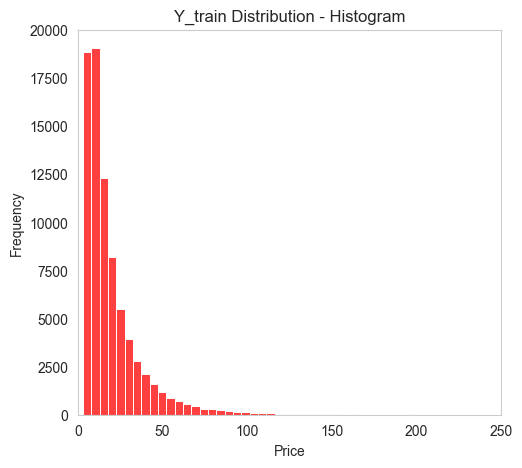

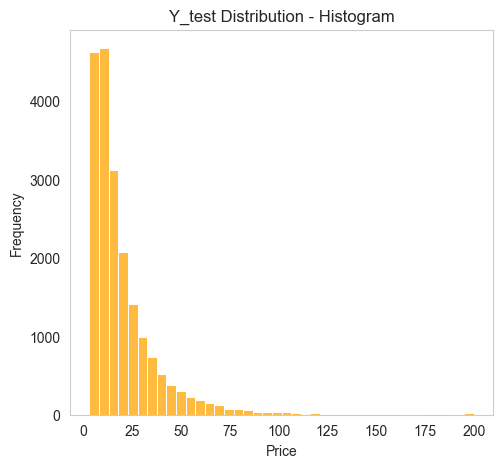

In [101]:

# Split the data appropriately:                     done
# Split data into 80% training and 20% testing      done
# Ensure reproducibility with random_state          done


# Verify the split maintains target distribution

# To verify split maintains target distribution I will plot the distribution of the target variable (price) in both training and testing sets using histograms.

plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1) 
sns.histplot(Y_train, bins=40, color='red')
plt.title('Y_train Distribution - Histogram')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xlim(0, 250)  # Limit x-axis for better visibility
plt.grid()
plt.show()


plt.figure(figsize=(12, 5))

# Histogram
plt.subplot(1, 2, 1) 
sns.histplot(Y_test, bins=40, color='orange')
plt.title('Y_test Distribution - Histogram')
plt.xlabel('Price')
plt.ylabel('Frequency')
#plt.xlim(0, 250)  # Limit x-axis for better visibility
plt.grid()
plt.show()

# The histograms of Y_train and Y_test show similar right-skewed distributions with most prices below $50 and a long tail of higher prices. 
# This indicates that the train-test split has maintained the target variable's distribution well.



# Question 4.3: Linear Regression (4 points)

In [102]:
# Implement and evaluate Linear Regression:
# Train the model
# Make predictions on test set
# Calculate RMSE, MAE, and R²
# Analyze residuals and model assumptions

In [103]:
from sklearn.linear_model import LinearRegression

# Building the Linear Regression model

linear_model = LinearRegression()
linear_model.fit(X_train, Y_train) # based on training data


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [104]:
# Make predictions on the test set
y_pred = linear_model.predict(X_test)
print(y_pred)

# Here i see a -ve value in y-pred

#[14.03300576 -0.44049706 10.05002818 ... 19.41203313  4.80647481 ,13.56901091]

[10.66914104 -3.26318486 10.27615651 ... 17.40529924  4.03948217
 14.48953583]


In [105]:
# Evaluate the model

from sklearn.metrics import mean_squared_error, r2_score

linear_mse = mean_squared_error(Y_test, y_pred)
linear_r2 = r2_score(Y_test, y_pred)


linear_rmse = np.sqrt(linear_mse)

from sklearn.metrics import mean_absolute_error

linear_mae = mean_absolute_error(Y_test, y_pred)

print ("   ** Linear Regression Model Evalutaion **\n")
print(f"R² : {linear_r2:.3f}")
print(f"MAE: {linear_mae:.3f}")
print(f"MSE: {linear_mse:.3f}")
print(f"RMSE: {linear_rmse:.3f}")



   ** Linear Regression Model Evalutaion **

R² : 0.841
MAE: 4.789
MSE: 57.276
RMSE: 7.568


# Question 4.4: Decision Tree Regression (4 points)


In [106]:
# Implement and evaluate Decision Tree Regression:
# Train with default parameters first
# Evaluate performance
# Visualize the tree (first few levels)
# Identify important features

In [107]:
from sklearn.tree import DecisionTreeRegressor


# Create and Train the Model with decision tree regressor
tree = DecisionTreeRegressor(max_depth=3, random_state=42)  # max_depth controls tree size
tree.fit(X_train, Y_train)



,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [108]:
# Make Predictions
tree_y_pred = tree.predict(X_test)
print(tree_y_pred)

# [13.29742977  8.49594409 18.0553194  ... 26.46763215 13.29742977 ,13.29742977]

[13.29742977  8.49594409 18.0553194  ... 26.46763215 13.29742977
 13.29742977]


In [109]:
# Evaluate



tree_r2   = r2_score(Y_test, tree_y_pred)
tree_mae  = mean_absolute_error(Y_test, tree_y_pred)
tree_mse  = mean_squared_error(Y_test, tree_y_pred)
tree_rmse = np.sqrt(tree_mse)


print ("   ** Decision Tree Regressor Model Evalutaion **\n")
print(f"R² : {tree_r2:.3f}")
print(f"MAE: {tree_mae:.3f}")
print(f"MSE: {tree_mse:.3f}")
print(f"RMSE: {tree_rmse:.3f}")


   ** Decision Tree Regressor Model Evalutaion **

R² : 0.681
MAE: 6.574
MSE: 114.786
RMSE: 10.714


In [110]:
from sklearn.tree import DecisionTreeRegressor, export_text

print(export_text(tree, feature_names=list(X.columns)))

|--- duration_minutes <= 0.76
|   |--- duration_minutes <= -0.22
|   |   |--- duration_minutes <= -0.57
|   |   |   |--- value: [8.50]
|   |   |--- duration_minutes >  -0.57
|   |   |   |--- value: [13.30]
|   |--- duration_minutes >  -0.22
|   |   |--- vehicle_type_Standard <= 0.50
|   |   |   |--- value: [26.47]
|   |   |--- vehicle_type_Standard >  0.50
|   |   |   |--- value: [18.06]
|--- duration_minutes >  0.76
|   |--- duration_minutes <= 3.02
|   |   |--- vehicle_type_Standard <= 0.50
|   |   |   |--- value: [51.14]
|   |   |--- vehicle_type_Standard >  0.50
|   |   |   |--- value: [34.26]
|   |--- duration_minutes >  3.02
|   |   |--- vehicle_type_Standard <= 0.50
|   |   |   |--- value: [98.42]
|   |   |--- vehicle_type_Standard >  0.50
|   |   |   |--- value: [69.86]



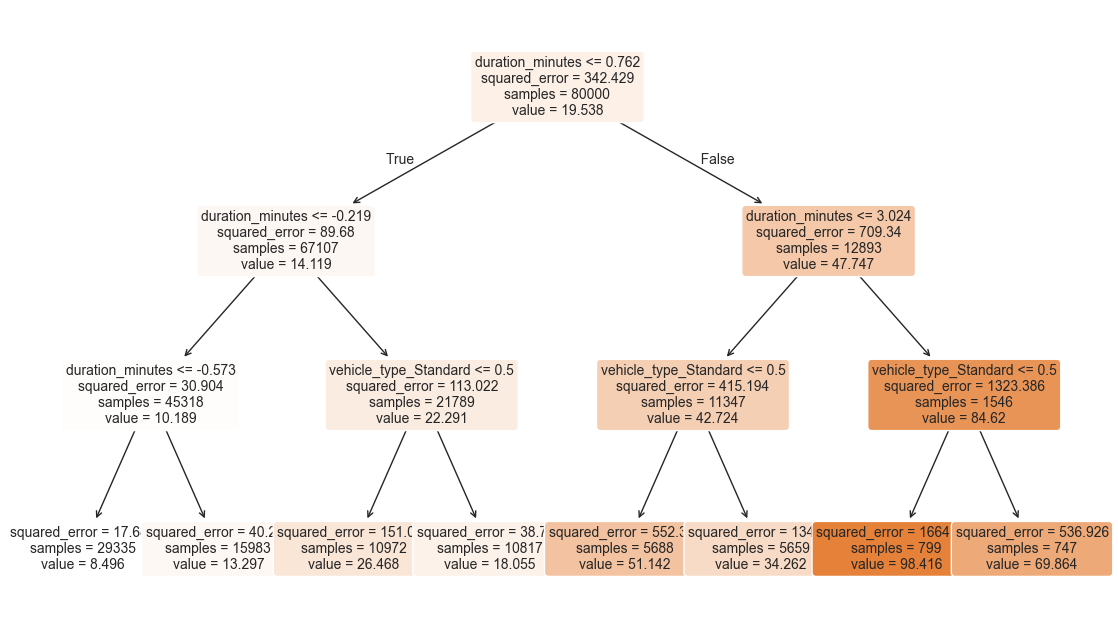

In [111]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Model is already trained
# tree = DecisionTreeRegressor(max_depth=5, random_state=42)
# tree.fit(X_train, y_train)

plt.figure(figsize=(14, 8))   # Adjust size for readability

# Show only the top 3 levels of the tree
plot_tree(tree,
          feature_names=X_train.columns,   # Column names of your features
          filled=True,                     # Color nodes by value
          rounded=True,                     # Rounded corners
          max_depth=3,                      # Limit visualization depth
          fontsize=10)

plt.show()


In [112]:
print(tree.feature_importances_)
X.columns
# I want to print side by side


[0.        0.9185509 0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.        0.        0.0814491
 0.        0.        0.        0.        0.        0.        0.
 0.        0.        0.        0.        0.       ]


Index(['distance_miles', 'duration_minutes', 'temperature', 'driver_rating',
       'is_weekend', 'is_rush_hour', 'trip_speed_mph', 'weather_Cloudy',
       'weather_Heavy Rain', 'weather_Light Rain', 'weather_Snow',
       'vehicle_type_Premium', 'vehicle_type_Shared', 'vehicle_type_Standard',
       'dropoff_location_Business', 'dropoff_location_Downtown',
       'dropoff_location_Entertainment', 'dropoff_location_Residential',
       'pickup_location_Business', 'pickup_location_Downtown',
       'pickup_location_Entertainment', 'pickup_location_Residential',
       'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'],
      dtype='object')

In [113]:


# Combine into a DataFrame
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree.feature_importances_
})

# Sort by importance (optional)
feat_importance = feat_importance.sort_values(by='Importance', ascending=False)

print(feat_importance)


# Imporatant features as per decision tree regressor model are:
# duration_minutes
# vehicle_type_Standard

                           Feature  Importance
1                 duration_minutes    0.918551
13           vehicle_type_Standard    0.081449
2                      temperature    0.000000
3                    driver_rating    0.000000
4                       is_weekend    0.000000
5                     is_rush_hour    0.000000
6                   trip_speed_mph    0.000000
7                   weather_Cloudy    0.000000
8               weather_Heavy Rain    0.000000
0                   distance_miles    0.000000
9               weather_Light Rain    0.000000
10                    weather_Snow    0.000000
11            vehicle_type_Premium    0.000000
12             vehicle_type_Shared    0.000000
14       dropoff_location_Business    0.000000
15       dropoff_location_Downtown    0.000000
16  dropoff_location_Entertainment    0.000000
17    dropoff_location_Residential    0.000000
18        pickup_location_Business    0.000000
19        pickup_location_Downtown    0.000000
20   pickup_l

# Question 4.5: Random Forest Regression (5 points)


In [114]:
# Implement and evaluate Random Forest Regression:
# Train with default parameters
# Evaluate performance
# Extract feature importance
# Compare with single Decision Tree performance

In [115]:
from sklearn.ensemble import RandomForestRegressor

# Create the model
rf = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=3,        #  trees grow until 3 same as deciosion tree regressor
    random_state=42
)

# Fit model
rf.fit(X_train, Y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [116]:
rf_y_pred = rf.predict(X_test)
print(rf_y_pred)


[13.45592768  8.536011   18.23566944 ... 26.72304575 13.45592768
 13.50369636]


In [117]:
rf_r2   = r2_score(Y_test, rf_y_pred)
rf_mae  = mean_absolute_error(Y_test, rf_y_pred)
rf_mse  = mean_squared_error(Y_test, rf_y_pred)
rf_rmse = np.sqrt(rf_mse)


print ("   ** Random Forest (rf) Regressor Model Evalutaion **\n")
print(f"R² : {rf_r2:.3f}")
print(f"MAE: {rf_mae:.3f}")
print(f"MSE: {rf_mse:.3f}")
print(f"RMSE: {rf_rmse:.3f}")

   ** Random Forest (rf) Regressor Model Evalutaion **

R² : 0.703
MAE: 6.367
MSE: 106.916
RMSE: 10.340


In [118]:
                      


                #                    R2          MAE         MSE        RMSE

   # Linear Regression               0.841     4.789      57.276      7.568
   # Decision Tree Regressor         0.681     6.574     114.786     10.714
   # Random Forest (rf) Regressor    0.703     6.367     106.916     10.340


# R² high (near 1) → model fits data well. 

# MAE/RMSE low → predictions are close to actual prices.

# RMSE > MAE → indicates some large outliers (because RMSE penalizes big errors more).


In [119]:
rf_feat_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(rf_feat_importances)


                           Feature  Importance
1                 duration_minutes    0.931229
13           vehicle_type_Standard    0.068616
12             vehicle_type_Shared    0.000155
3                    driver_rating    0.000000
2                      temperature    0.000000
5                     is_rush_hour    0.000000
6                   trip_speed_mph    0.000000
7                   weather_Cloudy    0.000000
4                       is_weekend    0.000000
0                   distance_miles    0.000000
9               weather_Light Rain    0.000000
8               weather_Heavy Rain    0.000000
11            vehicle_type_Premium    0.000000
10                    weather_Snow    0.000000
14       dropoff_location_Business    0.000000
15       dropoff_location_Downtown    0.000000
16  dropoff_location_Entertainment    0.000000
17    dropoff_location_Residential    0.000000
18        pickup_location_Business    0.000000
19        pickup_location_Downtown    0.000000
20   pickup_l

In [120]:
                #                    R2          MAE         MSE        RMSE

   # Decision Tree Regressor         0.681     6.574     114.786     10.714
   # Random Forest (rf) Regressor    0.703     6.367     106.916     10.340

# Random Forest slightly outperforms single Decision Tree .



# Question 4.6: Voting Regressor (5 points)


In [121]:
# Implement a Voting Regressor:
# Combine Linear Regression, Decision Tree, and Random Forest
# Use both hard and soft voting if applicable
# Compare ensemble performance with individual models
# Discuss the benefits of ensemble methods

In [122]:
from sklearn.ensemble import  VotingRegressor



#  Create individual models
lr = LinearRegression()
dt = DecisionTreeRegressor(random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Combine them in a Voting Regressor
voting_reg = VotingRegressor(estimators=[
    ('lr', lr),
    ('dt', dt),
    ('rf', rf)
])

# Fit model
voting_reg.fit(X_train, Y_train)


,estimators,"[('lr', ...), ('dt', ...), ...]"
,weights,None
,n_jobs,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
,criterion,'squared_error'
,splitter,'best'


In [123]:
# Make predictions
vr_y_pred = voting_reg.predict(X_test)
print(vr_y_pred)

[ 8.48228035  1.81897171 12.1293855  ... 18.10736641  4.92232739
 15.45597861]


In [124]:
# Evaluate
vr_mse = mean_squared_error(Y_test, vr_y_pred)
vr_rmse = np.sqrt(vr_mse)
vr_r2 = r2_score(Y_test, vr_y_pred)
vr_mae  = mean_absolute_error(Y_test, vr_y_pred)


print("    Voting Regressor Performance:    ")
print(f"R² : {vr_r2:.3f}")
print(f"MAE: {vr_mae:.3f}")
print(f"MSE: {vr_mse:.3f}")
print(f"RMSE: {vr_rmse:.3f}")

    Voting Regressor Performance:    
R² : 0.930
MAE: 2.982
MSE: 25.277
RMSE: 5.028


In [125]:
 #                                   R2          MAE         MSE        RMSE

   # Linear Regression               0.841     4.789      57.276      7.568
   # Decision Tree Regressor         0.681     6.574     114.786     10.714
   # Random Forest (rf) Regressor    0.703     6.367     106.916     10.340  
   # Voting Regressor                0.930     2.982      25.277      5.028

# The Voting Regressor outperforms all individual models, achieving the highest R² and lowest MAE, MSE, and RMSE.
# Ensemble method combines predictions of multiple regressors. The final prediction is the average of all model outputs (mean of predicted numbers).

# Question 5.1: Performance Comparison (8 points)


In [126]:
# Create comprehensive performance comparison:
# Build a comparison table with all models and metrics (RMSE, MAE, R²)
# Create visualizations comparing model performances
# Perform cross-validation for more robust evaluation
# Identify the best performing model

In [127]:

# Create the results as a DataFrame
results = {
    'Model': ['Linear Regression',
              'Decision Tree Regressor',
              'Random Forest Regressor',
              'Voting Regressor'],
    'R2':   [0.841, 0.681, 0.703, 0.930],
    'MAE':  [4.789, 6.574, 6.367, 2.982],
    'MSE':  [57.276, 114.786, 106.916, 25.277],
    'RMSE': [7.568, 10.714, 10.340, 5.028]
}

df_results = pd.DataFrame(results)
print(df_results)

                     Model     R2    MAE      MSE    RMSE
0        Linear Regression  0.841  4.789   57.276   7.568
1  Decision Tree Regressor  0.681  6.574  114.786  10.714
2  Random Forest Regressor  0.703  6.367  106.916  10.340
3         Voting Regressor  0.930  2.982   25.277   5.028


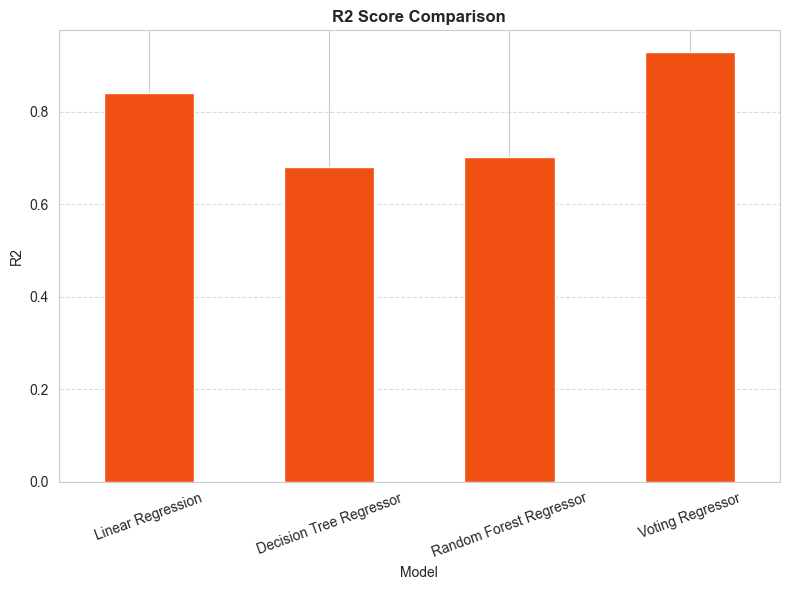

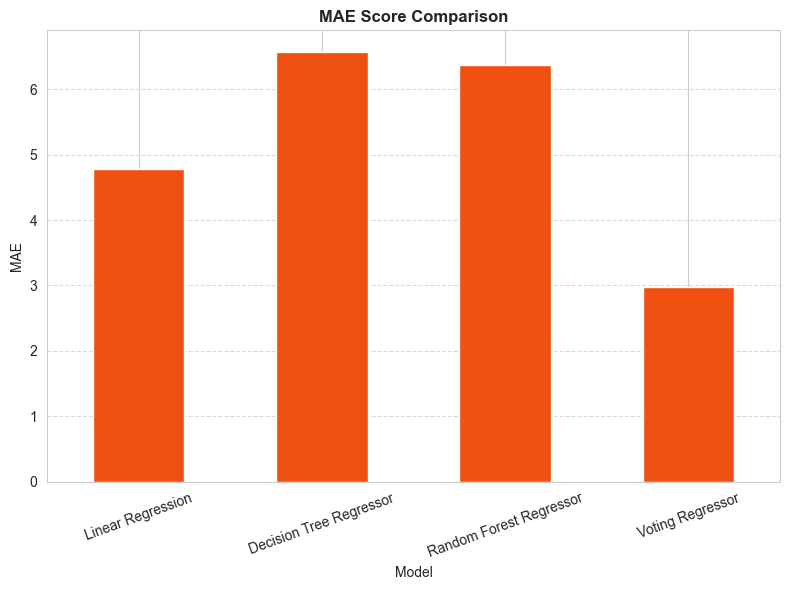

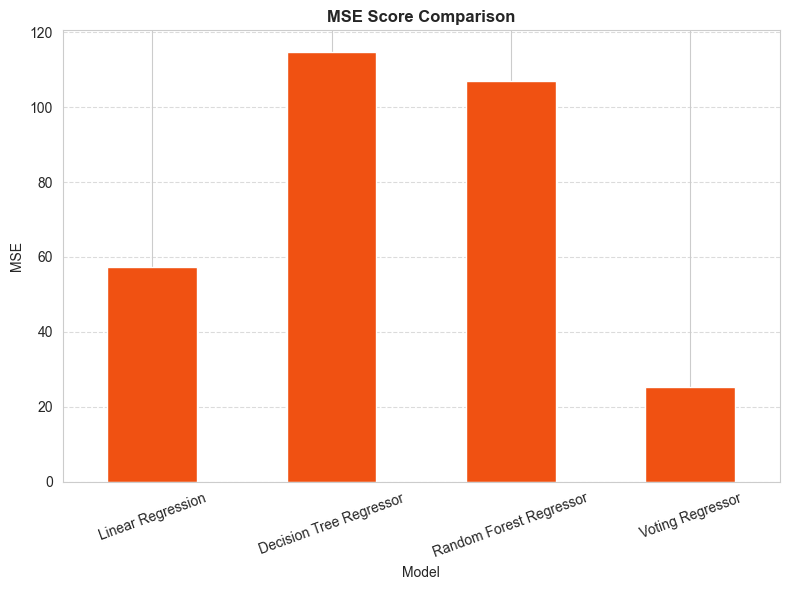

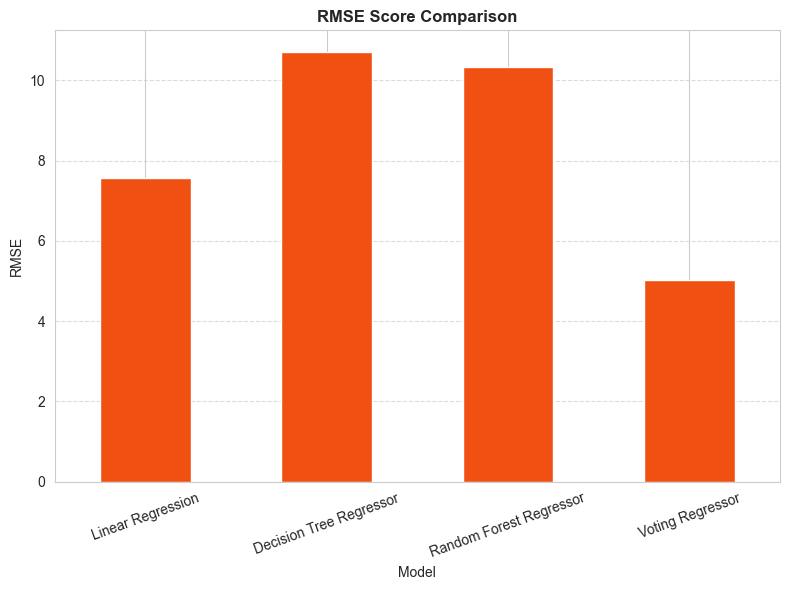

In [128]:
score_columns = ['R2', 'MAE', 'MSE', 'RMSE']
 # Set model names as index for easier plotting
df_results.set_index('Model', inplace=True)
for col in score_columns:
    plt.figure(figsize=(8,6))
    df_results[col].plot(kind='bar', color="#F05112")
    plt.title(f'{col} Score Comparison', fontsize=12, weight='bold')
    plt.ylabel(df_results[col].name)
    plt.xlabel('Model')
    plt.xticks(rotation=20)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()



In [129]:
#               Interpretation :

# The Voting Regressor outperforms all individual models, achieving the highest R² and lowest MAE, MSE, and RMSE.
# Ensemble method combines predictions of multiple regressors. The final prediction is the average of all model outputs (mean of predicted numbers).

In [130]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
X_scaled = X[numeric_cols] = scaler.fit_transform(X[numeric_cols]) 


In [131]:
from sklearn.model_selection import cross_val_score

score1 = cross_val_score(linear_model, X, Y, cv=kf, scoring="r2")   
print("Linear Model KFold " , score1)


Linear Model KFold  [0.84091592 0.82745908 0.83453178 0.82817557 0.83635908]


In [132]:

score2 = cross_val_score(tree, X, Y, cv=kf, scoring="r2")
print("Decision Tree KFold ", score2)

Decision Tree KFold  [0.68118558 0.67130853 0.68496369 0.6641444  0.67803898]


In [133]:
score3 = cross_val_score(rf, X, Y, cv=kf, scoring='r2')
print("Random Forest KFold ", score3)

Random Forest KFold  [0.94051706 0.93617933 0.94190232 0.93804219 0.94222545]


In [134]:
# Linear Model KFold  [0.84091592 0.82745908 0.83453178 0.82817557 0.83635908]

# Decision Tree KFold  [0.68118558 0.67130853 0.68496369 0.6641444  0.67803898]

# Random Forest KFold  [0.94051706 0.93617933 0.94190232 0.93804219 0.94222545]

In [135]:
# I choose linear model KFold for streamlit app development

# End of Coding with RideEase dataset.